In [2]:
# ==========================================
# 0. DEPENDENCIES & SETUP
# ==========================================
!pip install gymnasium stable-baselines3 shimmy numpy matplotlib

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import os

# Create directories for models
os.makedirs("models", exist_ok=True)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.0 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


LOW-LEVEL

In [ ]:


# ==========================================
# 1. PHYSICS ENGINE (Mock 6-DOF)
# ==========================================
class Mock6DOFAircraft:
    """
    Lightweight 6-DOF physics for RL training.
    """
    def __init__(self):
        self.dt = 0.1
        self.state = {}
        self.reset()

    def reset(self, alt=5000.0, speed=300.0, pitch=0.0, roll=0.0, heading=0.0):
        self.state = {
            'x': 0.0, 'y': 0.0, 'z': float(alt),
            'u': float(speed), 'v': 0.0, 'w': 0.0,
            'phi': np.radians(float(roll)),
            'theta': np.radians(float(pitch)),
            'psi': np.radians(float(heading)),
            'p': 0.0, 'q': 0.0, 'r': 0.0,
            'nz': 1.0
        }
        return self.state

    def step(self, action):
        # Action: [elevator, aileron, rudder, throttle]
        elevator, aileron, rudder, throttle = action

        # 1. Moments
        dp = (aileron * 2.0 - self.state['p'] * 0.5) * self.dt
        dq = (elevator * 1.0 - self.state['q'] * 0.5) * self.dt
        dr = (rudder * 0.5 - self.state['r'] * 0.5) * self.dt

        self.state['p'] += dp
        self.state['q'] += dq
        self.state['r'] += dr

        # 2. Kinematics
        self.state['phi'] += self.state['p'] * self.dt
        self.state['theta'] += self.state['q'] * self.dt
        self.state['psi'] += self.state['r'] * self.dt

        # 3. Forces (G-Load)
        g = 9.81
        turn_g = (self.state['q'] * self.state['u']) / g
        self.state['nz'] = 1.0 * np.cos(self.state['phi']) + turn_g

        # 4. Position
        climb_rate = self.state['u'] * np.sin(self.state['theta'])
        self.state['z'] += climb_rate * self.dt

        turn_rate = (g * np.tan(self.state['phi'])) / (self.state['u'] + 1e-6)
        self.state['psi'] += turn_rate * self.dt

        self.state['x'] += self.state['u'] * np.cos(self.state['theta']) * np.cos(self.state['psi']) * self.dt
        self.state['y'] += self.state['u'] * np.cos(self.state['theta']) * np.sin(self.state['psi']) * self.dt

        return self.state

In [ ]:
# ==========================================
# 2. REWARD FUNCTIONS
# ==========================================
class ManeuverRewards:
    @staticmethod
    def calculate_smoothness(current, prev, lamb=0.1):
        if prev is None: return 0.0
        return -lamb * np.sum(np.square(current - prev))

    @staticmethod
    def calculate_energy(speed, alt, corner=300.0):
        if speed < 100: return -10.0 # Stall
        return np.exp(-0.5 * ((speed - corner)/50.0)**2)

    @staticmethod
    def reward_split_s(s, start_alt, start_heading, action, prev):
        """
        Enforces: Steady Entry -> Invert -> Dive (Lose Alt) -> Transition -> Steady Exit.
        """
        # ---------------------------------------------------------
        # 1. STATE & TARGET CALCULATIONS
        # ---------------------------------------------------------
        TARGET_ROLL_INV = np.pi # 180 deg (Inverted)
        TARGET_HEAD_REV = start_heading + np.pi # Reversed Heading

        # Angle Errors (with wrapping to handle -pi to pi transitions)
        roll_err_inv = np.abs(s['phi'] - TARGET_ROLL_INV)
        if roll_err_inv > np.pi: roll_err_inv = 2*np.pi - roll_err_inv

        roll_err_upright = np.abs(s['phi'])
        if roll_err_upright > np.pi: roll_err_upright = 2*np.pi - roll_err_upright

        pitch_err_lvl = np.abs(s['theta'])

        head_err_rev = np.abs(s['psi'] - TARGET_HEAD_REV)
        if head_err_rev > np.pi: head_err_rev = 2*np.pi - head_err_rev

        head_err_start = np.abs(s['psi'] - start_heading)
        if head_err_start > np.pi: head_err_start = 2*np.pi - head_err_start

        # Altitude Progress
        alt_lost = start_alt - s['z']

        reward = 0.0

        # ---------------------------------------------------------
        # 2. PHASE DETECTION & REWARD LOGIC
        # ---------------------------------------------------------

        # SEGMENT 1 & 2: STEADY LEVEL -> TRANSITION TO INVERT
        # Trigger: We are still on the original heading and haven't lost altitude yet.
        if alt_lost < 50 and head_err_start < 0.5:

            # GOAL: Roll to 180 degrees while keeping the nose strictly level.
            r_roll = np.exp(-2.0 * roll_err_inv)        # Reward approaching inverted
            r_pitch_hold = np.exp(-5.0 * pitch_err_lvl) # Strict reward for holding pitch=0

            # CONSTRAINT: Do not pull the stick yet!
            r_discipline = -5.0 if s['nz'] > 1.2 or action[0] > 0.15 else 0.0

            reward = r_roll + r_pitch_hold + r_discipline

        # SEGMENT 3: TRANSITION TO DIVE -> VERTICAL DIVE
        # Trigger: We started losing altitude, but haven't flipped heading yet.
        elif head_err_rev > 0.5:

            # GOAL: Pull Gs to dive through the vertical while holding inverted roll.
            # 1. Reward pulling Gs (Targeting around 4-7G)
            r_pull = (s['nz'] / 9.0) * 3.0 if s['nz'] > 0 else -5.0

            # 2. Reward actively losing altitude (Gravity Assist)
            r_descent = alt_lost / 200.0

            # 3. Constraint: Must hold 180 roll during the pull
            r_roll_hold = -1.0 * roll_err_inv

            # 4. Constraint: Loop must be strictly planar (No Yaw)
            r_planar = -2.0 * np.abs(s['r'])

            reward = r_pull + r_descent + r_roll_hold + r_planar

        # SEGMENT 4 & 5: TRANSITION TO STEADY LEVEL -> STEADY EXIT
        # Trigger: Heading is fully reversed (The bottom of the half-loop).
        else:

            # GOAL: Arrest descent, level the pitch, and roll upright.
            r_pitch_recover = np.exp(-4.0 * pitch_err_lvl)     # Reward pitch -> 0
            r_roll_recover = np.exp(-4.0 * roll_err_upright)   # Reward roll -> 0
            r_alt_arrest = np.exp(-0.05 * np.abs(s['w']))      # Reward vertical velocity (w) -> 0

            # Massive continuous bonus for achieving and holding this final state
            reward = (r_pitch_recover + r_roll_recover + r_alt_arrest) * 5.0 + 20.0

        # ---------------------------------------------------------
        # 3. GLOBAL CONSTRAINTS
        # ---------------------------------------------------------
        # Smoothness: Pilots don't jerk the stick
        if prev is not None:
            reward -= 0.1 * np.sum(np.square(action - prev))

        return reward

    @staticmethod
    def reward_break_turn(s, target_alt, action, prev):
        # Maximize turn rate * G
        r_perf = (s['nz'] / 9.0) * (np.abs(s['r']) / 0.5)
        r_alt = -np.abs(s['z'] - target_alt) / 50.0
        r_smooth = ManeuverRewards.calculate_smoothness(action, prev)
        return r_perf + r_alt + r_smooth

    @staticmethod
    def reward_rolling_scissors(s, bandit_x, bandit_y, action, prev):
        # Point at bandit, force overshoot (bandit_x > 0)
        angle_to_bandit = np.arctan2(bandit_y, bandit_x)
        r_align = np.exp(-2.0 * np.abs(s['psi'] - angle_to_bandit))
        r_over = 50.0 if bandit_x > 0 else 0
        r_smooth = ManeuverRewards.calculate_smoothness(action, prev)
        return r_align + r_over + r_smooth

    @staticmethod
    def reward_barrel_roll(s, total_roll, action, prev):
        # Coord p & q
        r_coord = np.abs(s['p']) * np.abs(s['q'])
        r_disp = np.abs(s['u'] * np.sin(s['theta'])) / 50.0
        r_comp = 100.0 if np.abs(total_roll) > 2*np.pi else 0
        r_smooth = ManeuverRewards.calculate_smoothness(action, prev)
        return r_coord + r_disp + r_comp + r_smooth

    @staticmethod
    def reward_high_g(s, target, action, prev):
        r_g = np.exp(-1.0 * np.abs(s['nz'] - target))
        r_smooth = ManeuverRewards.calculate_smoothness(action, prev)
        return r_g + r_smooth

    @staticmethod
    def reward_pull(s, target_pitch, action, prev):
        r_ang = -np.abs(s['theta'] - target_pitch)
        r_rate = -np.abs(s['q'] - np.clip(target_pitch - s['theta'], -1, 1))
        r_succ = 10.0 if np.abs(s['theta'] - target_pitch) < 0.1 else 0
        r_smooth = ManeuverRewards.calculate_smoothness(action, prev)
        return r_ang + r_rate + r_succ + r_smooth

In [ ]:
# ==========================================
# 3. BASE ENVIRONMENT
# ==========================================
class BaseManeuverEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Box(low=-1, high=1, shape=(4,), dtype=np.float32)
        # Obs: [phi, theta, psi, p, q, r, nz, z, u]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)
        self.sim = Mock6DOFAircraft()
        self.max_steps = 300
        self.current_step = 0
        self.prev_action = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.prev_action = None
        # Default reset (subclasses override this)
        return self.get_obs(), {}

    def get_obs(self):
        s = self.sim.state
        return np.array([
            s['phi'], s['theta'], s['psi'],
            s['p'], s['q'], s['r'],
            s['nz'], s['z'], s['u']
        ], dtype=np.float32)

    def step(self, action):
        # Placeholder (subclasses override)
        raise NotImplementedError

# ==========================================
# 4. SPECIFIC MANEUVER ENVIRONMENTS
# ==========================================
class EnhancedSplitSEnv(gym.Env):
    def __init__(self):
        super().__init__()
        # Actions: [Elevator, Aileron, Rudder, Throttle]
        self.action_space = spaces.Box(low=-1, high=1, shape=(4,), dtype=np.float32)

        # Observations: [Roll, Pitch, Heading, P, Q, R, Nz, Alt, Speed]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

        self.sim = Mock6DOFAircraft() # Assuming the Mock 6-DOF physics engine
        self.max_steps = 300 # Increased slightly to allow time for the full stabilized exit
        self.current_step = 0
        self.prev_action = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.prev_action = None

        # Start: High Altitude, Steady Level Flight
        self.sim.reset(alt=6000.0, speed=300.0, heading=0.0, pitch=0.0, roll=0.0)
        self.start_heading = 0.0
        self.start_alt = 6000.0

        return self.get_obs(), {}

    def get_obs(self):
        s = self.sim.state
        return np.array([
            s['phi'], s['theta'], s['psi'],
            s['p'], s['q'], s['r'],
            s['nz'], s['z'], s['u']
        ], dtype=np.float32)

    def step(self, action):
        # Step Physics
        self.sim.step(action)
        self.current_step += 1
        s = self.sim.state

        # 1. Calculate Phase-Based Reward
        # (This calls the 5-segment reward function written in the previous step)
        reward = ManeuverRewards.reward_split_s(
            s, self.start_alt, self.start_heading, action, self.prev_action
        )
        self.prev_action = action

        # 2. CHECK "STOP" CONDITION (Steady Exit)
        # We stop the maneuver ONLY when:
        # A. Heading is reversed (We completed the half-loop)
        # B. We are flying Level (Pitch ~ 0)
        # C. We are Upright (Roll ~ 0)
        # D. We lost altitude (We actually dove, didn't just turn around flat)
        # E. NEW: Vertical Velocity is near zero (We fully arrested the dive and are STEADY)

        # Calculate Heading Error (Reciprocal)
        target_heading = self.start_heading + np.pi
        h_err = np.abs(s['psi'] - target_heading)
        if h_err > np.pi: h_err = 2*np.pi - h_err

        # Vertical velocity (w component = speed * sin(pitch))
        vertical_velocity = s['u'] * np.sin(s['theta'])

        # Gate Checks
        is_reversed = h_err < 0.2                 # Approx 11 deg tolerance
        is_level_pitch = np.abs(s['theta']) < 0.1 # Approx 5 deg tolerance
        is_upright = np.abs(s['phi']) < 0.1       # Approx 5 deg tolerance
        lost_altitude = (self.start_alt - s['z']) > 500 # Lost at least 500m
        is_steady = np.abs(vertical_velocity) < 5.0     # Sink/climb rate is less than 5 m/s

        # All gates must be passed to finish the maneuver
        success = is_reversed and is_level_pitch and is_upright and lost_altitude and is_steady

        # 3. TERMINATION LOGIC
        terminated = False

        if success:
            reward += 100.0 # Massive "Mission Accomplished" bonus
            terminated = True # STOP SIMULATION IMMEDIATELY

        # Fail conditions: Ground collision or running out of time
        if s['z'] < 0 or self.current_step >= self.max_steps:
            reward -= 50.0 # Penalty for crashing or failing to complete the maneuver in time
            terminated = True

        return self.get_obs(), reward, terminated, False, {}

class EnhancedBreakTurnEnv(BaseManeuverEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.sim.reset(alt=3000, speed=450)
        self.target_alt = 3000
        return self.get_obs(), {}

    def step(self, action):
        self.sim.step(action)
        self.current_step += 1
        s = self.sim.state

        rew = ManeuverRewards.reward_break_turn(s, self.target_alt, action, self.prev_action)
        self.prev_action = action

        term = (s['u'] < 100) or (s['z'] < 0) or (self.current_step >= self.max_steps)
        return self.get_obs(), rew, term, False, {}

class EnhancedScissorsEnv(BaseManeuverEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.sim.reset(alt=4000, speed=350, heading=0)
        self.bandit_x = -300.0; self.bandit_y = 50.0; self.bandit_v = 400.0
        return self.get_obs(), {}

    def step(self, action):
        self.sim.step(action)
        self.current_step += 1
        s = self.sim.state

        self.bandit_x += (self.bandit_v - s['u']) * 0.1

        rew = ManeuverRewards.reward_rolling_scissors(s, self.bandit_x, self.bandit_y, action, self.prev_action)
        self.prev_action = action

        term = (self.bandit_x > 50) or (self.current_step >= self.max_steps)
        return self.get_obs(), rew, term, False, {}

class EnhancedBarrelRollEnv(BaseManeuverEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.sim.reset(alt=5000, speed=450)
        self.total_roll = 0.0; self.prev_phi = 0.0
        return self.get_obs(), {}

    def step(self, action):
        self.sim.step(action)
        self.current_step += 1
        s = self.sim.state

        dr = s['phi'] - self.prev_phi
        if dr < -np.pi: dr += 2*np.pi
        if dr > np.pi: dr -= 2*np.pi
        self.total_roll += dr
        self.prev_phi = s['phi']

        rew = ManeuverRewards.reward_barrel_roll(s, self.total_roll, action, self.prev_action)
        self.prev_action = action

        term = (np.abs(self.total_roll) > 2.1*np.pi) or (self.current_step >= self.max_steps)
        return self.get_obs(), rew, term, False, {}

class EnhancedHighGEnv(BaseManeuverEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.sim.reset(alt=3000, speed=550)
        return self.get_obs(), {}

    def step(self, action):
        self.sim.step(action)
        self.current_step += 1
        s = self.sim.state
        rew = ManeuverRewards.reward_high_g(s, 9.0, action, self.prev_action)
        self.prev_action = action
        term = (self.current_step >= self.max_steps)
        return self.get_obs(), rew, term, False, {}

class EnhancedPullEnv(BaseManeuverEnv):
    def __init__(self, target_pitch=np.pi/2):
        super().__init__()
        self.target_pitch = target_pitch
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.sim.reset(alt=4000, speed=400, pitch=np.random.uniform(-0.2,0.2))
        return self.get_obs(), {}
    def step(self, action):
        self.sim.step(action)
        self.current_step += 1
        s = self.sim.state
        rew = ManeuverRewards.reward_pull(s, self.target_pitch, action, self.prev_action)
        self.prev_action = action
        term = (np.abs(s['theta']-self.target_pitch) < 0.05) or (self.current_step >= self.max_steps)
        return self.get_obs(), rew, term, False, {}

--- Training Split_S (25000 steps) ---


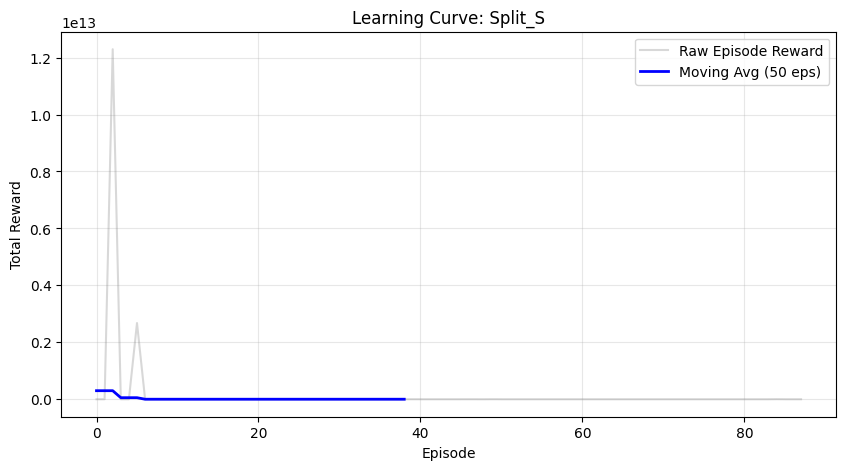

--- Training Break_Turn (25000 steps) ---


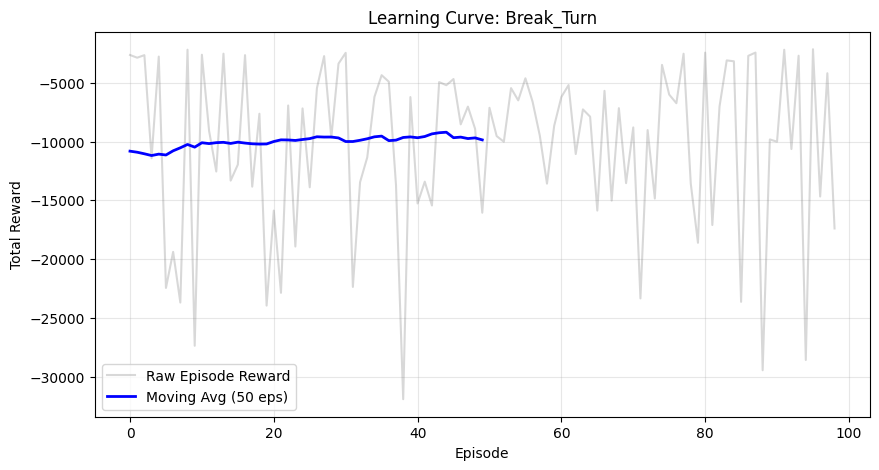

--- Training Rolling_Scissors (30000 steps) ---


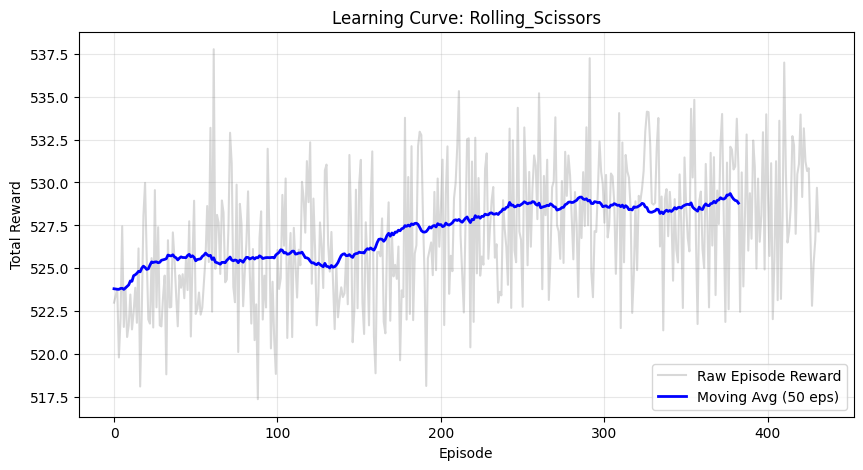

--- Training Barrel_Roll (30000 steps) ---


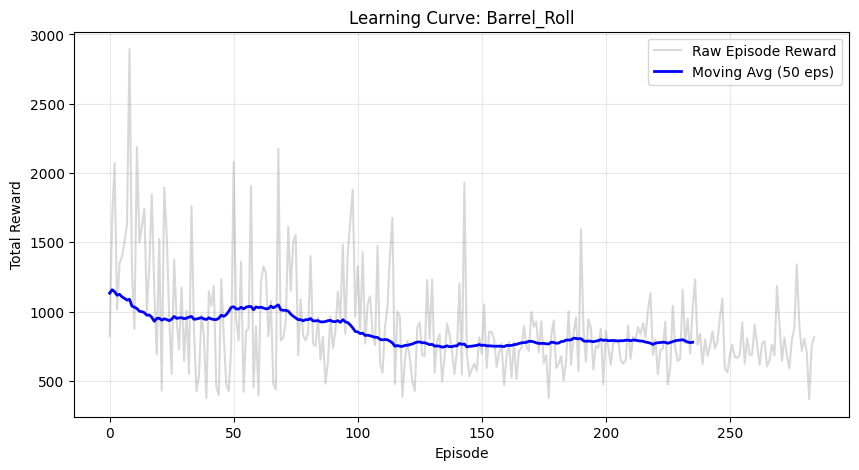

--- Training High_G (20000 steps) ---


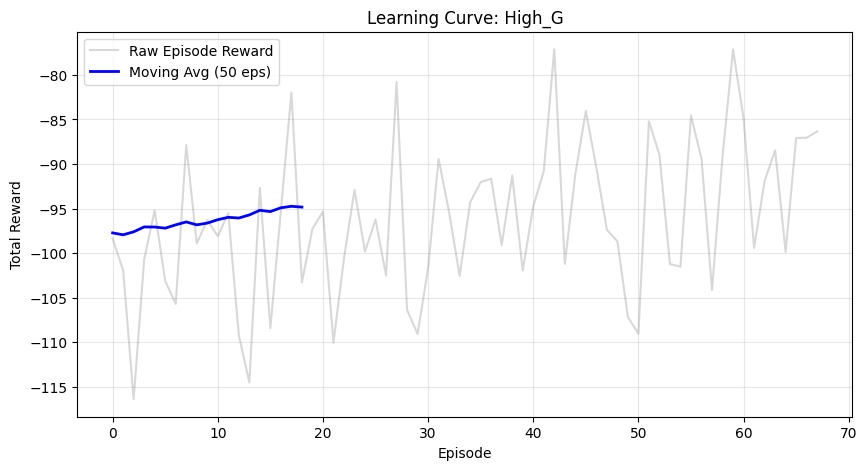

--- Training Pull (20000 steps) ---


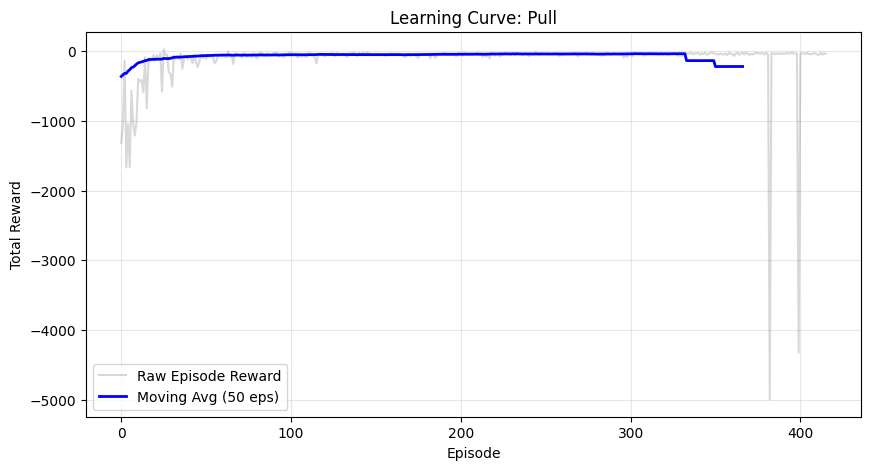

In [ ]:
# ==========================================
# 1. PLOTTING UTILITIES
# ==========================================
def moving_average(values, window):
    """
    Smooths the data using a simple moving average.
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

def plot_results(rewards, name, window=50):
    """
    Plots the raw reward data and the smoothed curve.
    """
    plt.figure(figsize=(10, 5))

    # Plot 1: Raw Data (Light color)
    plt.plot(rewards, alpha=0.3, color='gray', label='Raw Episode Reward')

    # Plot 2: Smoothed Data (Solid color)
    if len(rewards) > window:
        smoothed = moving_average(rewards, window)
        plt.plot(smoothed, color='blue', linewidth=2, label=f'Moving Avg ({window} eps)')

    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 2. TRAINING & PLOTTING LOOP
# ==========================================
def train_and_visualize(env_class, name, total_timesteps=20000):
    print(f"--- Training {name} ({total_timesteps} steps) ---")

    # 1. Wrap Environment with Monitor to capture stats
    env = Monitor(env_class())

    # 2. Initialize Agent
    # We use a lower learning rate (3e-4) for stability
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4)

    # 3. Train
    model.learn(total_timesteps=total_timesteps)

    # 4. Save
    model.save(f"models/{name}_policy")

    # 5. Extract & Plot
    episode_rewards = env.get_episode_rewards()
    plot_results(episode_rewards, name)

    return model

# ==========================================
# 3. EXECUTE FOR ALL MANEUVERS
# ==========================================

# Train & Plot Split-S
train_and_visualize(EnhancedSplitSEnv, "Split_S", total_timesteps=25000)

# Train & Plot Break Turn
train_and_visualize(EnhancedBreakTurnEnv, "Break_Turn", total_timesteps=25000)

# Train & Plot Rolling Scissors
train_and_visualize(EnhancedScissorsEnv, "Rolling_Scissors", total_timesteps=30000)

# Train & Plot Barrel Roll
train_and_visualize(EnhancedBarrelRollEnv, "Barrel_Roll", total_timesteps=30000)

# Train & Plot High G
train_and_visualize(EnhancedHighGEnv, "High_G", total_timesteps=20000)

# Train & Plot Pull
train_and_visualize(EnhancedPullEnv, "Pull", total_timesteps=20000)


--- Simulating Perfect Engagement: Split_S ---
Maneuver concluded at t=29.9s


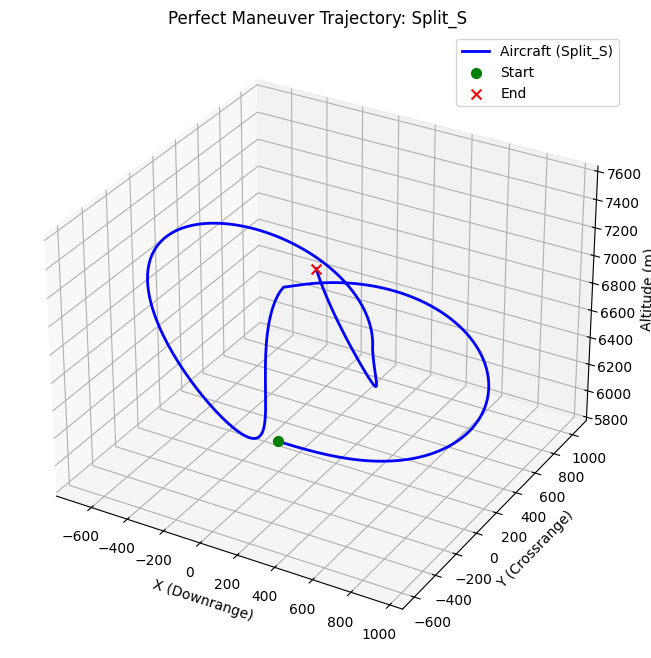


--- Simulating Perfect Engagement: Break_Turn ---
Maneuver concluded at t=14.0s


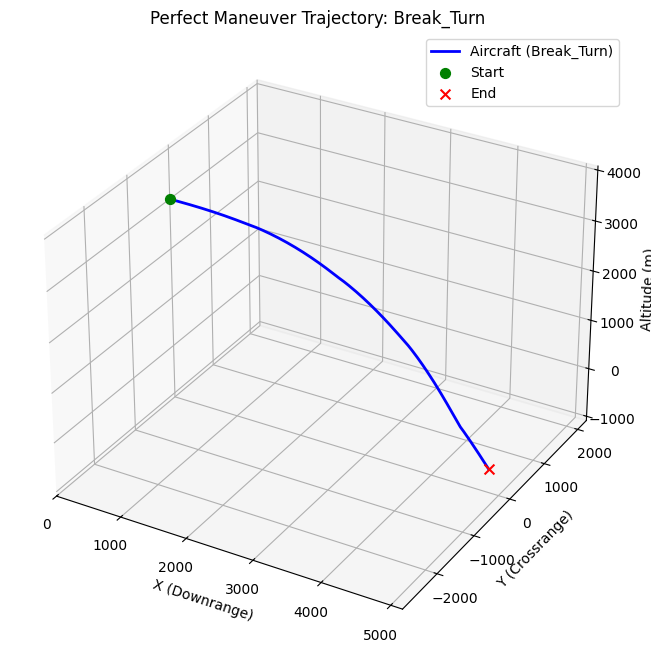


--- Simulating Perfect Engagement: Rolling_Scissors ---
Maneuver concluded at t=7.0s


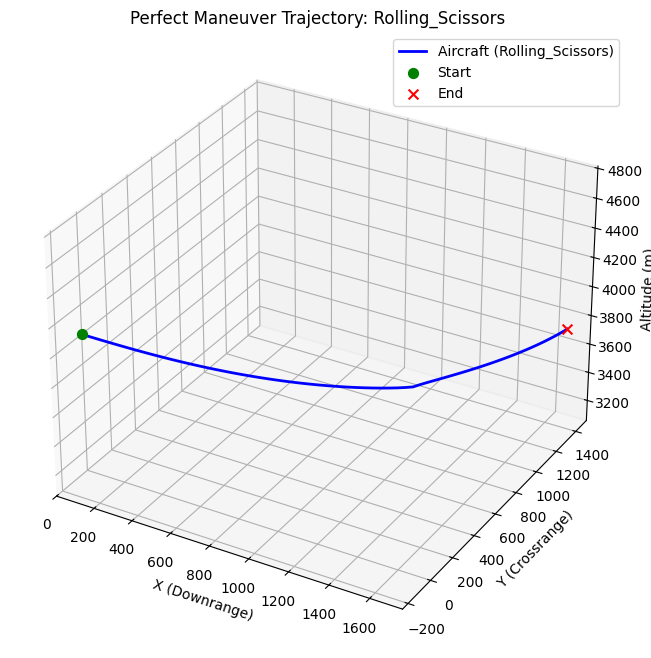


--- Simulating Perfect Engagement: Barrel_Roll ---
Maneuver concluded at t=6.1s


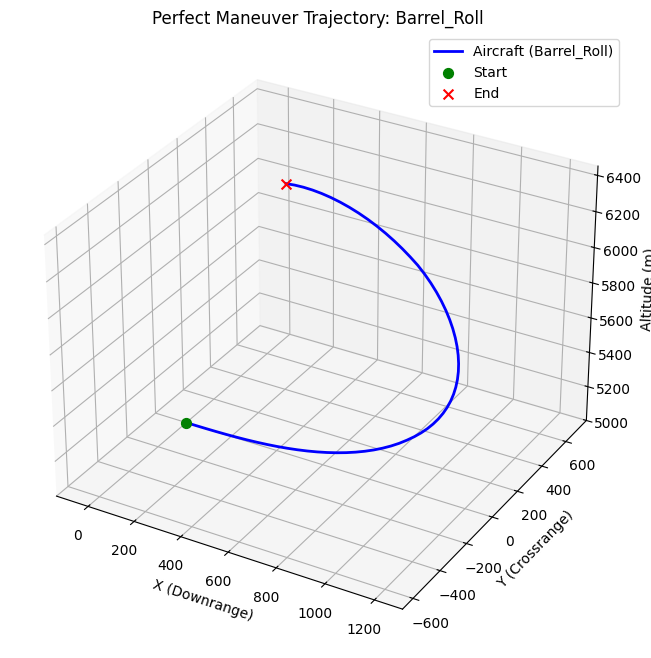


--- Simulating Perfect Engagement: High_G ---
Maneuver concluded at t=29.9s


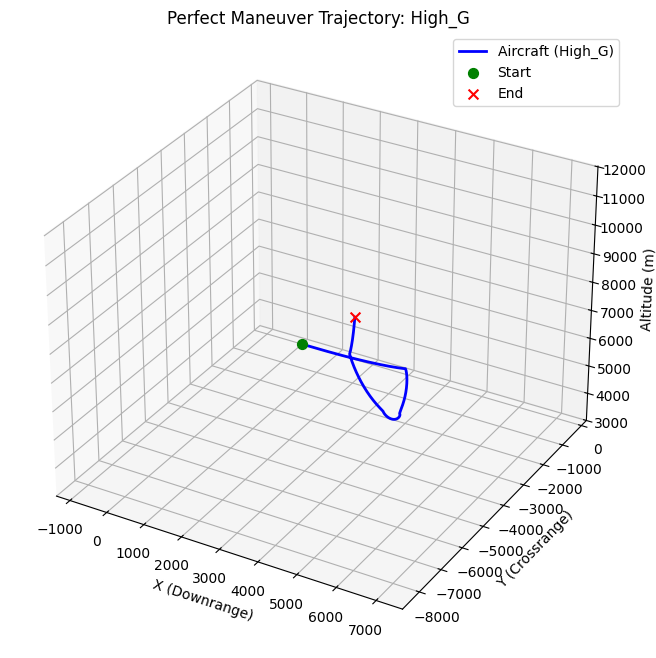

In [ ]:
"""
# ==========================================
# 6. EVALUATION SIMULATOR (Aircraft vs Missile)
# ==========================================
class AircraftEntity:
    #The Pilot (Blue Team)
    def __init__(self, start_pos):
        self.sim = Mock6DOFAircraft()
        self.sim.reset(alt=start_pos[2], heading=0)
        self.sim.state['x'] = start_pos[0]
        self.sim.state['y'] = start_pos[1]
        self.history = []

    def step(self, action):
        self.sim.step(action)
        s = self.sim.state
        self.history.append((s['x'], s['y'], s['z']))
        return s

class MissileEntity:
    #The Pursuer (Red Team) - PN Guidance
    def __init__(self, start_pos, target_pos):
        self.pos = np.array(start_pos, dtype=float)
        self.vel = np.array([0, 0, 0], dtype=float)
        self.speed = 600.0
        self.dt = 0.1
        self.max_g = 25.0

        # Point at target
        d = np.array(target_pos) - self.pos
        self.vel = d / np.linalg.norm(d) * self.speed
        self.history = []

    def step(self, target_pos):
        self.history.append(self.pos.copy())

        # 1. LOS Rate
        r_vec = np.array(target_pos) - self.pos
        dist = np.linalg.norm(r_vec)
        los = r_vec / (dist + 1e-6)

        # 2. Closing Velocity
        # Approximate closing velocity vector along LOS
        v_close = self.speed # Simplification for pure pursuit

        # 3. PN Acceleration Command (Simplified)
        # Accel direction = LOS direction (Pure Pursuit / Lead)
        # We steer velocity vector towards LOS
        desired_vel = los * self.speed

        # 4. Update Velocity (Rate Limited by G)
        dv = desired_vel - self.vel
        accel_req = dv / self.dt
        accel_mag = np.linalg.norm(accel_req)

        if accel_mag > (self.max_g * 9.81):
            accel_req = (accel_req / accel_mag) * (self.max_g * 9.81)

        self.vel += accel_req * self.dt
        self.vel = self.vel / np.linalg.norm(self.vel) * self.speed

        self.pos += self.vel * self.dt

        return dist < 20.0 # Hit

def run_clean_engagement(maneuver_name):
    # Load Model
    try:
        model = PPO.load(f"models/{maneuver_name}_policy")
    except:
        print(f"Model {maneuver_name} not found. Train first.")
        return

    # Env just for obs normalization
    if maneuver_name == "Split_S": env_cls = EnhancedSplitSEnv
    elif maneuver_name == "Break_Turn": env_cls = EnhancedBreakTurnEnv
    elif maneuver_name == "Rolling_Scissors": env_cls = EnhancedScissorsEnv
    elif maneuver_name == "Barrel_Roll": env_cls = EnhancedBarrelRollEnv
    elif maneuver_name == "High_G": env_cls = EnhancedHighGEnv
    else: env_cls = EnhancedPullEnv

    dummy_env = env_cls()

    # Initialize Combatants
    ac = AircraftEntity(start_pos=[0,0,5000])
    #ms = MissileEntity(start_pos=[-4000, 1000, 5000], target_pos=[0,0,5000])

    #hit = False

    print(f"Simulating Engagement: {maneuver_name}...")
    for t in range(50):
        # 1. Get Action from Brain
        obs = dummy_env.get_obs() # Just for shape
        # Inject real state into observation
        s = ac.sim.state
        real_obs = np.array([s['phi'], s['theta'], s['psi'], s['p'], s['q'], s['r'], s['nz'], s['z'], s['u']])

        action, _ = model.predict(real_obs, deterministic=True)

        # 2. Step Physics
        ac_state = ac.step(action)
        #ms_hit = ms.step([ac_state['x'], ac_state['y'], ac_state['z']])

        #if ms_hit:
            #hit = True
            #print("SPLASH - Missile Hit.")
            #break

    # Plot
    ac_hist = np.array(ac.history)
    #ms_hist = np.array(ms.history)

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(ac_hist[:,0], ac_hist[:,1], ac_hist[:,2], 'b-', label='Aircraft')
    #ax.plot(ms_hist[:,0], ms_hist[:,1], ms_hist[:,2], 'r--', label='Missile')
    ax.set_title(f"{maneuver_name} Engagement")
    ax.legend()
    plt.show()

# ==========================================
# 7. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":


    # 2. Evaluate
    run_clean_engagement("Split_S")
    run_clean_engagement("Break_Turn")
    run_clean_engagement("Rolling_Scissors")
    run_clean_engagement("Barrel_Roll")
    run_clean_engagement("High_G")
    run_clean_engagement("Pull")
"""
# ==========================================
# 6. EVALUATION SIMULATOR (Perfect Maneuver Sync)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from stable_baselines3 import PPO

def run_perfect_maneuver(maneuver_name):
    print(f"\n--- Simulating Perfect Engagement: {maneuver_name} ---")

    # 1. Load the exact environment used for training
    if maneuver_name == "Split_S": env_cls = EnhancedSplitSEnv
    elif maneuver_name == "Break_Turn": env_cls = EnhancedBreakTurnEnv
    elif maneuver_name == "Rolling_Scissors": env_cls = EnhancedScissorsEnv
    elif maneuver_name == "Barrel_Roll": env_cls = EnhancedBarrelRollEnv
    elif maneuver_name == "High_G": env_cls = EnhancedHighGEnv
    elif maneuver_name == "Pull": env_cls = EnhancedPullEnv
    else:
        print("Unknown maneuver!")
        return

    env = env_cls()

    # 2. Load Model
    try:
        model = PPO.load(f"models/{maneuver_name}_policy")
    except Exception as e:
        print(f"Model {maneuver_name} not found. Please train it first! Error: {e}")
        return

    # 3. Reset to perfect starting conditions defined in the Env
    obs, _ = env.reset()

    ac_hist = []

    # 4. Run until the maneuver is officially completed
    # Allow up to 300 steps (30 seconds) for complex maneuvers
    for t in range(300):
        # Log position from the environment's internal simulator
        s = env.sim.state
        ac_hist.append((s['x'], s['y'], s['z']))

        # Get Action
        action, _ = model.predict(obs, deterministic=True)

        # Step Physics
        obs, reward, terminated, truncated, _ = env.step(action)

        # If the environment says we succeeded (or crashed), stop!
        if terminated or truncated:
            # Capture final frame
            s = env.sim.state
            ac_hist.append((s['x'], s['y'], s['z']))
            print(f"Maneuver concluded at t={t*0.1:.1f}s")
            break

    # 5. Plotting
    ac_hist = np.array(ac_hist)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot Trajectory
    ax.plot(ac_hist[:,0], ac_hist[:,1], ac_hist[:,2], 'b-', linewidth=2, label=f'Aircraft ({maneuver_name})')

    # Mark Start and End points clearly
    ax.scatter(ac_hist[0,0], ac_hist[0,1], ac_hist[0,2], color='green', s=50, label='Start')
    ax.scatter(ac_hist[-1,0], ac_hist[-1,1], ac_hist[-1,2], color='red', marker='x', s=50, label='End')

    ax.set_title(f"Perfect Maneuver Trajectory: {maneuver_name}")
    ax.set_xlabel('X (Downrange)')
    ax.set_ylabel('Y (Crossrange)')
    ax.set_zlabel('Altitude (m)')

    # Force equal aspect ratio so loops look circular, not squashed
    # (Matplotlib 3D aspect ratio trick)
    max_range = np.array([
        ac_hist[:,0].max()-ac_hist[:,0].min(),
        ac_hist[:,1].max()-ac_hist[:,1].min(),
        ac_hist[:,2].max()-ac_hist[:,2].min()
    ]).max() / 2.0

    mid_x = (ac_hist[:,0].max()+ac_hist[:,0].min()) * 0.5
    mid_y = (ac_hist[:,1].max()+ac_hist[:,1].min()) * 0.5
    mid_z = (ac_hist[:,2].max()+ac_hist[:,2].min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.legend()
    plt.show()

# ==========================================
# 7. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    run_perfect_maneuver("Split_S")
    run_perfect_maneuver("Break_Turn")
    run_perfect_maneuver("Rolling_Scissors")
    run_perfect_maneuver("Barrel_Roll")
    run_perfect_maneuver("High_G")

HIGH - LEVEL

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO

class EnhancedEvasionEnv(gym.Env):
    def __init__(self, pilot_models):
        super(EnhancedEvasionEnv, self).__init__()

        # Action Space: 7 Discrete Maneuvers
        self.action_space = spaces.Discrete(7)

        # Observation Space: [Dist, Closing_V, Aspect_Angle, LOS_Rate, Alt, Own_V]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)

        self.pilots = pilot_models
        self.ac = AircraftEntity(start_pos=[0,0,5000])
        self.ms = MissileEntity(start_pos=[-4000, 1000, 5000], target_pos=[0,0,5000])

        self.max_steps = 1000
        self.current_step = 0
        self.prev_dist = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0

        # Robust Random Initialization
        ac_alt = np.random.uniform(4000, 6000)
        self.ac = AircraftEntity(start_pos=[0, 0, ac_alt])

        # Missile starts 3-6km away
        m_dist = np.random.uniform(3000, 6000)
        m_angle = np.random.uniform(-0.5, 0.5)
        mx = -m_dist * np.cos(m_angle)
        my = m_dist * np.sin(m_angle)

        self.ms = MissileEntity(start_pos=[mx, my, ac_alt], target_pos=[0,0,ac_alt])

        # Initialize distance tracking
        self.prev_dist = np.linalg.norm(self.ms.pos - np.array([0,0,ac_alt]))

        return self._get_obs(), {}

    def _get_geometry(self):
        # Extract Vectors
        ac_pos = np.array([self.ac.sim.state['x'], self.ac.sim.state['y'], self.ac.sim.state['z']])
        ms_pos = self.ms.pos
        ac_vel = np.array([self.ac.sim.state['u'], 0, 0]) # Simplified Body Frame
        # In a full sim, rotate ac_vel by theta/psi to get Inertial Velocity

        # Relative Position Vector (Range Vector)
        r_vec = ms_pos - ac_pos
        dist = np.linalg.norm(r_vec)

        # Line of Sight (LOS) Unit Vector
        los_vec = r_vec / (dist + 1e-6)

        # Aspect Angle (Angle between AC Velocity and LOS)
        # We normalize vectors first
        v_norm = ac_vel / (np.linalg.norm(ac_vel) + 1e-6)
        dot_product = np.dot(v_norm, los_vec)
        aspect_angle = np.arccos(np.clip(dot_product, -1.0, 1.0))

        # Closing Speed (Approximation)
        closing_speed = self.ms.speed - self.ac.sim.state['u']

        return dist, closing_speed, aspect_angle

    def _get_obs(self):
        dist, closing, aspect = self._get_geometry()

        # Simple LOS Rate approx (Change in aspect over time could be used, or just 0)
        los_rate = 0.0

        return np.array([
            dist,
            closing,
            aspect,
            los_rate,
            self.ac.sim.state['z'],
            self.ac.sim.state['u']
        ], dtype=np.float32)

    def step(self, action_idx):
        # 1. Select the Pilot based on Action Index
        if action_idx == 0: pilot = self.pilots["Split_S"]
        elif action_idx == 1: pilot = self.pilots["Break_Turn"]
        elif action_idx == 2: pilot = self.pilots["Rolling_Scissors"]
        elif action_idx == 3: pilot = self.pilots["Barrel_Roll"]
        else: pilot = self.pilots["High_G"]
        #else: pilot = self.pilots["Pull"]

        # 2. Hierarchical Execution: Run the selected maneuver for k steps
        # This prevents the high-level agent from switching minds every 0.1s
        k_steps = 10 # Decision Interval (1.0 second)
        total_reward = 0
        terminated = False
        hit = False

        for _ in range(k_steps):
            # A. Step Physics
            s = self.ac.sim.state
            pilot_obs = np.array([s['phi'], s['theta'], s['psi'], s['p'], s['q'], s['r'], s['nz'], s['z'], s['u']])
            low_action, _ = pilot.predict(pilot_obs, deterministic=True)

            ac_state = self.ac.step(low_action)
            hit = self.ms.step([ac_state['x'], ac_state['y'], ac_state['z']])

            # B. Calculate Geometry for Reward
            curr_dist, _, aspect = self._get_geometry()

            # --- ENHANCED REWARD CALCULATION ---

            # 1. Miss Distance Rate (Repulsive)
            # Reward = Change in distance.
            # If distance increases (running away), reward is positive.
            r_miss = (curr_dist - self.prev_dist) * 1.0

            # 2. Notch Reward (Orthogonal)
            # We want sin(aspect) to be 1 (90 degrees).
            # This forces the missile to turn hardest.
            r_notch = np.abs(np.sin(aspect)) * 0.5

            # 3. Energy Penalty
            # Don't slow down below 200m/s if missile is close (<2000m)
            r_energy = 0.0
            if s['u'] < 200 and curr_dist < 2000:
                r_energy = -1.0

            # 4. Step Survival Bonus
            r_exist = 0.1

            step_reward = r_miss + r_notch + r_energy + r_exist

            # Critical Termination
            if hit:
                step_reward = -1000.0 # Death Penalty
                terminated = True

            total_reward += step_reward
            self.prev_dist = curr_dist

            if terminated: break

        self.current_step += 1
        if self.current_step >= self.max_steps:
            terminated = True
            if not hit: total_reward += 1000.0 # Survival Bonus

        return self._get_obs(), total_reward, terminated, False, {}

Loading Low-Level Pilots...
Initializing High-Level Environment...
Using cpu device
Wrapping the env in a DummyVecEnv.
Training Tactician (High-Level Strategy)...
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 154       |
|    ep_rew_mean     | -4.84e+03 |
| time/              |           |
|    fps             | 225       |
|    iterations      | 1         |
|    time_elapsed    | 9         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 172          |
|    ep_rew_mean          | -4.78e+03    |
| time/                   |              |
|    fps                  | 216          |
|    iterations           | 2            |
|    time_elapsed         | 18           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 7.628073e-05 |
|    clip_frac

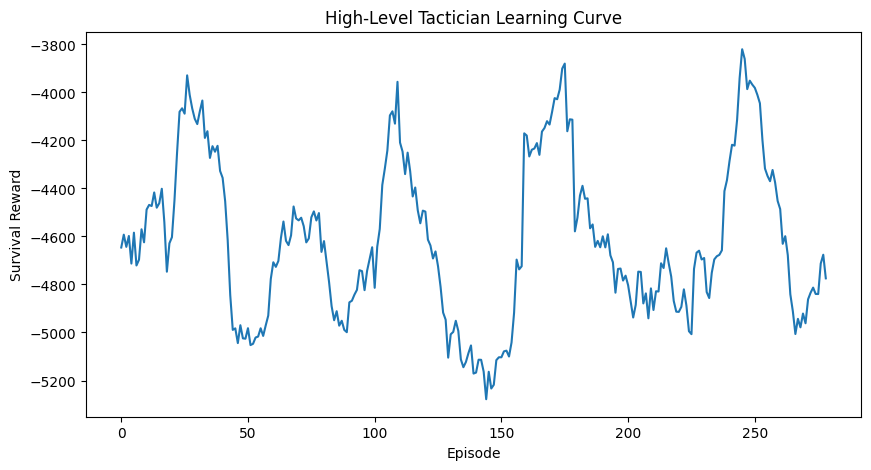

In [ ]:
# ==========================================
# 2. LOAD PILOTS & TRAIN TACTICIAN
# ==========================================

def train_tactician():
    print("Loading Low-Level Pilots...")
    pilots = {}
    try:
        pilots["Split_S"] = PPO.load("models/Split_S_policy")
        pilots["Break_Turn"] = PPO.load("models/Break_Turn_policy")
        pilots["Rolling_Scissors"] = PPO.load("models/Rolling_Scissors_policy")
        pilots["Barrel_Roll"] = PPO.load("models/Barrel_Roll_policy")
        pilots["High_G"] = PPO.load("models/High_G_policy")
        #pilots["Pull"] = PPO.load("models/models/Pull_policy") # Check path from training step
        #pilots["Pull_Down"] = PPO.load("models/models/Pull_Down_policy")
    except Exception as e:
        print(f"Error loading pilots: {e}")
        print("Please ensure you ran the 'train_all_pilots' function successfully.")
        return

    print("Initializing High-Level Environment...")
    env = Monitor(EnhancedEvasionEnv(pilots))

    # Initialize PPO for the Tactician
    # This model only learns to output 0-6 integers
    tactician = PPO("MlpPolicy", env, verbose=1, learning_rate=1e-4)

    print("Training Tactician (High-Level Strategy)...")
    tactician.learn(total_timesteps=50000)

    tactician.save("models/Tactician_Policy")
    print("Tactician Trained and Saved.")

    # Plot Learning Curve
    rewards = env.get_episode_rewards()
    smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')
    plt.figure(figsize=(10, 5))
    plt.plot(smoothed)
    plt.title("High-Level Tactician Learning Curve")
    plt.xlabel("Episode")
    plt.ylabel("Survival Reward")
    plt.show()

# Run it
train_tactician()

Running Tactical Evaluation...
T=0.0s | Tactician Chose: Barrel
T=1.0s | Tactician Chose: Barrel
T=2.0s | Tactician Chose: Barrel
T=3.0s | Tactician Chose: Barrel
T=4.0s | Tactician Chose: Barrel
T=5.0s | Tactician Chose: Barrel
T=6.0s | Tactician Chose: Barrel
T=7.0s | Tactician Chose: Barrel
T=8.0s | Tactician Chose: Barrel
T=9.0s | Tactician Chose: Barrel
T=10.0s | Tactician Chose: Barrel
T=11.0s | Tactician Chose: Barrel
T=12.0s | Tactician Chose: Barrel
T=13.0s | Tactician Chose: Barrel
T=14.0s | Tactician Chose: Barrel
T=15.0s | Tactician Chose: Barrel
T=16.0s | Tactician Chose: Barrel
T=17.0s | Tactician Chose: Barrel
T=18.0s | Tactician Chose: Barrel
T=19.0s | Tactician Chose: Barrel
T=20.0s | Tactician Chose: Barrel
T=21.0s | Tactician Chose: Barrel
T=22.0s | Tactician Chose: Barrel
T=23.0s | Tactician Chose: Barrel
T=24.0s | Tactician Chose: Barrel
T=25.0s | Tactician Chose: Barrel
T=26.0s | Tactician Chose: Barrel
T=27.0s | Tactician Chose: Barrel
T=28.0s | Tactician Chose: 

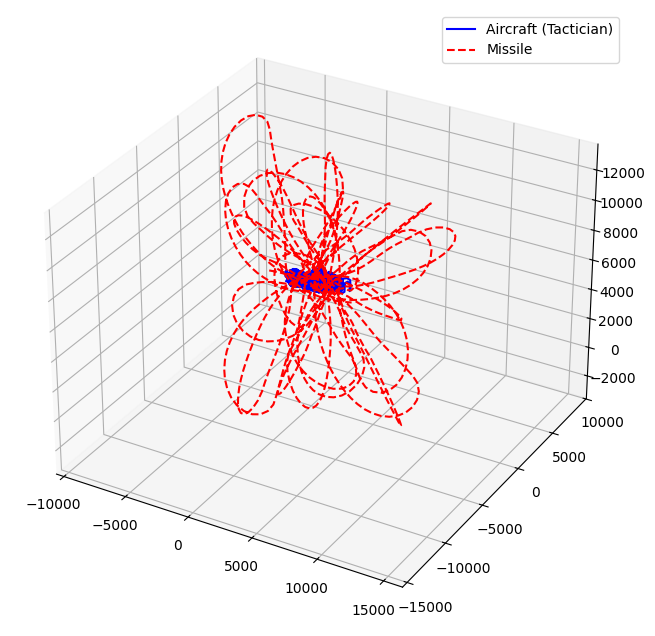

In [ ]:
def evaluate_tactician():
    # Load Models
    tactician = PPO.load("models/Tactician_Policy")

    # Load Pilots (Need to reload them for the eval function scope)
    pilots = {
        "Split_S": PPO.load("models/Split_S_policy"),
        "Break_Turn": PPO.load("models/Break_Turn_policy"),
        "Rolling_Scissors": PPO.load("models/Rolling_Scissors_policy"),
        "Barrel_Roll": PPO.load("models/Barrel_Roll_policy"),
        "High_G": PPO.load("models/High_G_policy"),
        #"Pull": PPO.load("models/models/Pull_policy"),
        #"Pull_Down": PPO.load("models/models/Pull_Down_policy")
    }

    env = EnhancedEvasionEnv(pilots)
    obs, _ = env.reset()

    print("Running Tactical Evaluation...")

    ac_hist = []
    ms_hist = []

    for t in range(1000): # 100 seconds
        # 1. Tactician decides maneuver (0-6)
        action_idx, _ = tactician.predict(obs, deterministic=True)

        # Map index to name for printing
        names = ["Split-S", "Break", "Scissors", "Barrel", "High-G", "Pull-Up", "Pull-Down"]
        if t % 10 == 0: print(f"T={t*0.1:.1f}s | Tactician Chose: {names[action_idx]}")

        # 2. Step Environment (Executes 10 steps of physics internally)
        obs, reward, terminated, _, _ = env.step(action_idx)

        # 3. Capture History (We need to pull history from the internal entities)
        # Note: EvasionEnv.step runs 10 internal steps, so we miss high-res plotting data
        # unless we modify step. For visual simplicity, we just plot the state at the decision points.
        s = env.ac.sim.state
        ac_hist.append((s['x'], s['y'], s['z']))

        ms_pos = env.ms.pos
        ms_hist.append((ms_pos[0], ms_pos[1], ms_pos[2]))

        if terminated:
            print("Engagement Over.")
            break

    # Plot
    ac_arr = np.array(ac_hist)
    ms_arr = np.array(ms_hist)

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(ac_arr[:,0], ac_arr[:,1], ac_arr[:,2], 'b-', label='Aircraft (Tactician)')
    ax.plot(ms_arr[:,0], ms_arr[:,1], ms_arr[:,2], 'r--', label='Missile')
    ax.legend()
    plt.show()

# Run Evaluation
evaluate_tactician()

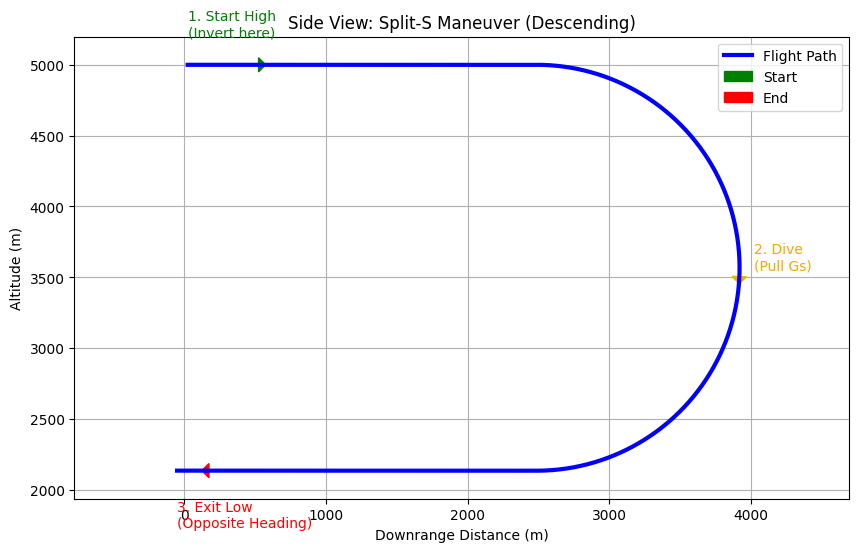

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SIMPLE SPLIT-S PHYSICS
# ==========================================
def simulate_descending_split_s():
    dt = 0.1

    # State: [x, z, pitch (theta), speed]
    # Starting High (5000m), flying Right (+x)
    x = 0.0
    z = 5000.0
    theta = 0.0 # Level flight
    speed = 250.0 # m/s

    history_x = []
    history_z = []

    # 1. STEADY FLIGHT (2 seconds)
    for _ in range(100):
        x += speed * dt
        history_x.append(x)
        history_z.append(z)

    # 2. INVERT (Roll 180) - Instantaneous for 2D profile
    # (In reality, we roll here, but altitude stays roughly same)

    # 3. DESCENDING HALF-LOOP (The "Split-S")
    # We pull Gs, which changes pitch from 0 -> -180 degrees
    # Since we are inverted, "Pulling" decreases pitch (0 -> -10 -> -90 -> -180)

    pitch_rate = np.radians(10.0) # 10 degrees per second pitch change (approx 4G)
    target_pitch = -np.pi # -180 degrees

    while theta > target_pitch:
        # Update Pitch (Pulling nose DOWN towards earth)
        theta -= pitch_rate * dt

        # Update Position based on Pitch
        # Vx = Speed * cos(theta)
        # Vz = Speed * sin(theta)
        vx = speed * np.cos(theta)
        vz = speed * np.sin(theta)

        x += vx * dt
        z += vz * dt # vz will be negative, so Z decreases

        history_x.append(x)
        history_z.append(z)

    # 4. EXIT (Level Flight in Opposite Direction)
    # Pitch is now -180 (flying backwards level)
    for _ in range(100):
        vx = speed * np.cos(target_pitch) # -Speed
        vz = speed * np.sin(target_pitch) # 0

        x += vx * dt
        z += vz * dt

        history_x.append(x)
        history_z.append(z)

    return history_x, history_z

# ==========================================
# 2. PLOTTING
# ==========================================
x_hist, z_hist = simulate_descending_split_s()

plt.figure(figsize=(10, 6))

# Plot the trajectory
plt.plot(x_hist, z_hist, linewidth=3, color='blue', label='Flight Path')

# Add Arrows to show direction
# Start arrow
plt.arrow(x_hist[10], z_hist[10], x_hist[20]-x_hist[10], 0,
          head_width=100, head_length=50, color='green', label='Start')
# Dive arrow
mid = len(x_hist)//2
plt.arrow(x_hist[mid], z_hist[mid], x_hist[mid+1]-x_hist[mid], z_hist[mid+1]-z_hist[mid],
          head_width=100, head_length=50, color='orange')
# End arrow
plt.arrow(x_hist[-20], z_hist[-20], x_hist[-10]-x_hist[-20], 0,
          head_width=100, head_length=50, color='red', label='End')

# Formatting
plt.title('Side View: Split-S Maneuver (Descending)')
plt.xlabel('Downrange Distance (m)')
plt.ylabel('Altitude (m)')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the circle shape proportional

# Annotations for clarity
plt.text(x_hist[0], z_hist[0]+200, "1. Start High\n(Invert here)", color='green')
plt.text(np.max(x_hist)+100, np.mean(z_hist), "2. Dive\n(Pull Gs)", color='orange')
plt.text(x_hist[-1], z_hist[-1]-400, "3. Exit Low\n(Opposite Heading)", color='red')

plt.show()

Initializing environment and starting PPO training...
Training complete. Running simulation rollout...


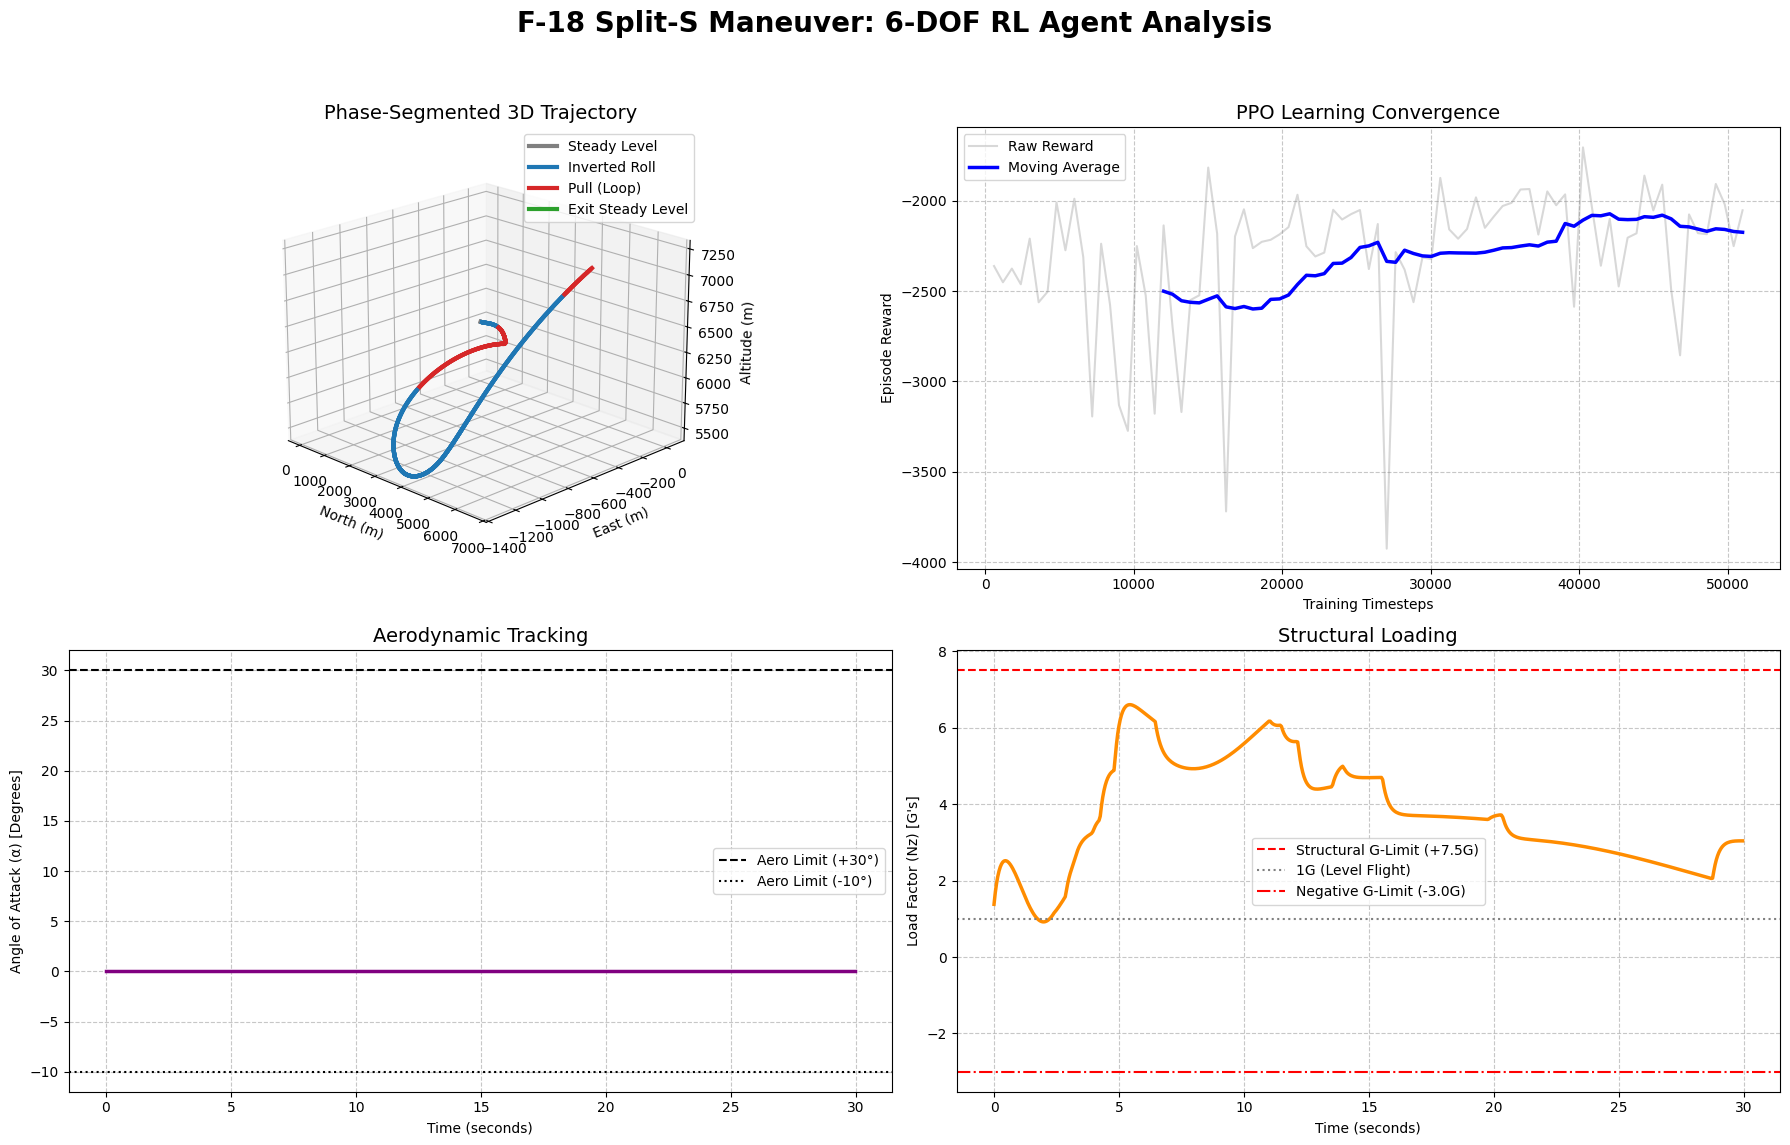

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import os
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy

# --- 1. The 6-DOF Environment ---
class F18SplitS6DOFEnv(gym.Env):
    def __init__(self):
        super().__init__()
        # Actions: [Elevator, Aileron, Rudder, Throttle] -> Normalized [-1, 1]
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        # States: [x, y, z, u, v, w, phi, theta, psi, p, q, r]
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.dt = 0.05
        self.g = 9.81
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Start at 6000m, Mach 0.8 (~270 m/s)
        self.state = np.array([0.0, 0.0, 6000.0, 270.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def step(self, action):
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        de, da, dr, dt_thr = action

        # Aircraft Limits
        max_roll_rate = np.radians(225.0)
        max_pitch_rate = np.radians(30.0)
        max_yaw_rate = np.radians(15.0)

        # Rotational Dynamics
        dp = (da * max_roll_rate - p) * 5.0
        dq = (de * max_pitch_rate - q) * 4.0
        dr_rate = (dr * max_yaw_rate - r) * 2.0

        p += dp * self.dt
        q += dq * self.dt
        r += dr_rate * self.dt

        # Euler Angle Rates
        dphi = p + q * np.sin(phi) * np.tan(theta) + r * np.cos(phi) * np.tan(theta)
        dtheta = q * np.cos(phi) - r * np.sin(phi)
        dpsi = (q * np.sin(phi) + r * np.cos(phi)) / (np.cos(theta) + 1e-8)

        phi += dphi * self.dt
        theta += dtheta * self.dt
        psi += dpsi * self.dt

        # Translational Dynamics
        V = np.sqrt(u**2 + v**2 + w**2) + 1e-8
        vx = V * np.cos(theta) * np.cos(psi)
        vy = V * np.cos(theta) * np.sin(psi)
        vz = V * np.sin(theta)

        x += vx * self.dt
        y += vy * self.dt
        z += vz * self.dt

        # Calculate Alpha (Angle of Attack) and Nz (Load Factor)
        vz_ratio = np.clip(vz / V, -1.0, 1.0)
        w_kin = V * np.sin(theta - np.arcsin(vz_ratio))
        u_kin = V * np.cos(theta - np.arcsin(vz_ratio)) + 1e-8

        alpha = np.degrees(np.arctan2(w_kin, u_kin))
        nz = (V * q) / self.g + np.cos(theta) * np.cos(phi)

        self.state = np.array([x, y, z, u_kin, v, w_kin, phi, theta, psi, p, q, r], dtype=np.float32)

        # Generalized Reward Function
        phi_err = abs(abs(phi) - np.pi) / np.pi
        psi_diff = (psi - np.pi + np.pi) % (2*np.pi) - np.pi
        psi_err = abs(psi_diff) / np.pi
        progress = 1.0 - psi_err
        theta_err = (abs(theta) / (np.pi/2)) * progress

        # Safety Penalties
        alpha_penalty = -0.5 if abs(alpha) > 30.0 else 0.0
        nz_penalty = -1.0 if nz > 7.5 or nz < -3.0 else 0.0
        rate_penalty = -0.01 * (p**2 + r**2)

        reward = -(1.5 * phi_err + 3.0 * psi_err + 2.0 * theta_err) + alpha_penalty + nz_penalty + rate_penalty

        self.steps += 1
        terminated = bool(z < 1000 or (psi_err < 0.05 and abs(theta) < 0.05 and abs(phi) < 0.05) or self.steps > 600)

        return self.state, reward, terminated, False, {'alpha': alpha, 'nz': nz}

# --- 2. Execution and Training ---
if __name__ == "__main__":
    log_dir = "./ppo_splits_logs/"
    os.makedirs(log_dir, exist_ok=True)

    print("Initializing environment and starting PPO training...")
    env = Monitor(F18SplitS6DOFEnv(), log_dir)

    # Train the model (Using a lower timestep count for demonstration speed; increase to 500k+ for true convergence)
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4, n_steps=2048, batch_size=64, gamma=0.99)
    model.learn(total_timesteps=50000)
    print("Training complete. Running simulation rollout...")

    # --- 3. Simulation Rollout ---
    obs, _ = env.reset()
    history, alphas, nzs, phases = [], [], [], []

    for t in range(600):
        # We use deterministic=True to test the best learned policy
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)

        history.append(obs.copy())
        alphas.append(info['alpha'])
        nzs.append(info['nz'])

        # Dynamically determine the flight phase for coloring the plot based on aircraft attitude
        phi_deg, theta_deg, psi_deg = np.degrees(obs[6]), np.degrees(obs[7]), np.degrees(obs[8])

        if t < 20 and abs(phi_deg) < 10:
            phases.append('Steady Level')
        elif abs(phi_deg) < 170 and abs(psi_deg) < 45:
            phases.append('Inverted Roll')
        elif abs(psi_deg) < 175:
            phases.append('Pull (Loop)')
        else:
            phases.append('Exit Steady Level')

        if done:
            break

    history = np.array(history)
    alphas = np.array(alphas)
    nzs = np.array(nzs)
    time_arr = np.arange(len(history)) * 0.05

    # Extract Learning Curve Data
    try:
        x_logs, y_logs = ts2xy(load_results(log_dir), 'timesteps')
        learning_curve_data = pd.Series(y_logs).rolling(window=20).mean().values
    except Exception as e:
        print("Could not load logs for learning curve:", e)
        x_logs, y_logs, learning_curve_data = [], [], []

    # --- 4. Plotting the 4-Panel Dashboard ---
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('F-18 Split-S Maneuver: 6-DOF RL Agent Analysis', fontsize=20, fontweight='bold')

    # Subplot 1: 3D Trajectory with Colored Phases
    ax1 = fig.add_subplot(221, projection='3d')
    phase_colors = {
        'Steady Level': '#808080',    # Gray
        'Inverted Roll': '#1f77b4',   # Blue
        'Pull (Loop)': '#d62728',     # Red
        'Exit Steady Level': '#2ca02c'# Green
    }

    for i in range(len(history) - 1):
        ax1.plot(history[i:i+2, 0], history[i:i+2, 1], history[i:i+2, 2],
                 color=phase_colors[phases[i]], linewidth=3)

    legend_elements = [Line2D([0], [0], color=c, lw=3, label=l) for l, c in phase_colors.items()]
    ax1.legend(handles=legend_elements, loc='upper right')
    ax1.set_xlabel('North (m)')
    ax1.set_ylabel('East (m)')
    ax1.set_zlabel('Altitude (m)')
    ax1.set_title('Phase-Segmented 3D Trajectory', fontsize=14)
    ax1.view_init(elev=20, azim=-45)

    # Subplot 2: PPO Learning Curve
    ax2 = fig.add_subplot(222)
    if len(x_logs) > 0:
        ax2.plot(x_logs, y_logs, alpha=0.3, color='gray', label='Raw Reward')
        ax2.plot(x_logs, learning_curve_data, color='blue', linewidth=2.5, label='Moving Average')
    ax2.set_xlabel('Training Timesteps')
    ax2.set_ylabel('Episode Reward')
    ax2.set_title('PPO Learning Convergence', fontsize=14)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    # Subplot 3: Angle of Attack (Alpha)
    ax3 = fig.add_subplot(223)
    ax3.plot(time_arr, alphas, color='purple', linewidth=2.5)
    ax3.axhline(y=30, color='black', linestyle='--', linewidth=1.5, label='Aero Limit (+30°)')
    ax3.axhline(y=-10, color='black', linestyle=':', linewidth=1.5, label='Aero Limit (-10°)')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Angle of Attack (\u03B1) [Degrees]')
    ax3.set_title('Aerodynamic Tracking', fontsize=14)
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.7)

    # Subplot 4: Load Factor (Nz)
    ax4 = fig.add_subplot(224)
    ax4.plot(time_arr, nzs, color='darkorange', linewidth=2.5)
    ax4.axhline(y=7.5, color='red', linestyle='--', linewidth=1.5, label='Structural G-Limit (+7.5G)')
    ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, label='1G (Level Flight)')
    ax4.axhline(y=-3.0, color='red', linestyle='-.', linewidth=1.5, label='Negative G-Limit (-3.0G)')
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Load Factor (Nz) [G\'s]')
    ax4.set_title('Structural Loading', fontsize=14)
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit main title
    plt.show()

In [ ]:
import gymnasium as gym
import numpy as np

class CurriculumF18Env(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.dt = 0.05
        self.g = 9.81
        self.curriculum_level = 0  # Start at Level 0
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([0.0, 0.0, 6000.0, 270.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def step(self, action):
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        de, da, dr, dt_thr = action

        # Aircraft Limits
        max_roll_rate = np.radians(225.0)
        max_pitch_rate = np.radians(30.0)
        max_yaw_rate = np.radians(15.0)

        # Rotational Dynamics
        dp = (da * max_roll_rate - p) * 5.0
        dq = (de * max_pitch_rate - q) * 4.0
        dr_rate = (dr * max_yaw_rate - r) * 2.0

        p += dp * self.dt
        q += dq * self.dt
        r += dr_rate * self.dt

        # Euler Angle Rates
        dphi = p + q * np.sin(phi) * np.tan(theta) + r * np.cos(phi) * np.tan(theta)
        dtheta = q * np.cos(phi) - r * np.sin(phi)
        dpsi = (q * np.sin(phi) + r * np.cos(phi)) / (np.cos(theta) + 1e-8)

        phi += dphi * self.dt
        theta += dtheta * self.dt
        psi += dpsi * self.dt

        # Translational Dynamics
        V = np.sqrt(u**2 + v**2 + w**2) + 1e-8
        vx = V * np.cos(theta) * np.cos(psi)
        vy = V * np.cos(theta) * np.sin(psi)
        vz = V * np.sin(theta)

        x += vx * self.dt
        y += vy * self.dt
        z += vz * self.dt

        # --- DYNAMIC REWARD FUNCTION BASED ON CURRICULUM ---
        phi_err = abs(abs(self.state[6]) - np.pi) / np.pi
        psi_err = abs((self.state[8] - np.pi + np.pi) % (2*np.pi) - np.pi) / np.pi

        if self.curriculum_level == 0:
            # Lesson 0: Fly Straight and Level
            # Target: phi = 0, theta = 0
            reward = - (abs(self.state[6]) + abs(self.state[7]))
            terminated = bool(self.state[2] < 5000 or self.steps > 200)

        elif self.curriculum_level == 1:
            # Lesson 1: Roll Inverted and Hold
            # Target: phi = 180 (pi), theta = 0
            reward = - (phi_err + abs(self.state[7]))
            terminated = bool(self.state[2] < 4000 or self.steps > 300)

        else:
            # Lesson 2: Full Split-S
            progress = 1.0 - psi_err
            theta_err = (abs(self.state[7]) / (np.pi/2)) * progress
            reward = -(1.5 * phi_err + 3.0 * psi_err + 2.0 * theta_err)
            terminated = bool(self.state[2] < 1000 or (psi_err < 0.05 and abs(self.state[7]) < 0.05))

        self.steps += 1

        # Prevent infinite loops if not terminated
        if self.steps > 600:
            terminated = True

        return self.state, reward, terminated, False, {}

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback

class CurriculumCallback(BaseCallback):
    """
    Custom callback for advancing the curriculum level.
    """
    def __init__(self, step_thresholds, verbose=0):
        super().__init__(verbose)
        # step_thresholds is a list: e.g., [100000, 250000]
        # At 100k steps, level -> 1. At 250k steps, level -> 2.
        self.step_thresholds = step_thresholds
        self.current_level = 0

    def _on_step(self) -> bool:
        # Check if we need to advance to the next level
        if self.current_level < len(self.step_thresholds):
            if self.num_timesteps >= self.step_thresholds[self.current_level]:
                self.current_level += 1
                if self.verbose > 0:
                    print(f"\n[Curriculum] Timesteps reached: {self.num_timesteps}.")
                    print(f"[Curriculum] Upgrading environment to Level {self.current_level}!\n")

                # Update the environment parameter
                # Note: self.training_env is a vectorized environment
                self.training_env.set_attr('curriculum_level', self.current_level)

        return True

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

if __name__ == "__main__":
    # 1. Initialize Vectorized Environment
    env = DummyVecEnv([lambda: Monitor(CurriculumF18Env())])

    # 2. Define the Lesson Plan
    # Level 0 for 50k steps -> Level 1 for 100k steps -> Level 2 for the rest
    thresholds = [50000, 150000]
    curriculum_callback = CurriculumCallback(step_thresholds=thresholds, verbose=1)

    # 3. Setup PPO Agent
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4, n_steps=2048, batch_size=64)

    # 4. Train with Curriculum
    print("Initiating Flight School (Curriculum Training)...")
    total_training_steps = 400000
    model.learn(total_timesteps=total_training_steps, callback=curriculum_callback)

    print("Training Complete. Agent is ready for full Split-S rollout.")
    model.save("f18_splits_curriculum_agent")

Initiating Flight School (Curriculum Training)...

[Curriculum] Timesteps reached: 50000.
[Curriculum] Upgrading environment to Level 1!


[Curriculum] Timesteps reached: 150000.
[Curriculum] Upgrading environment to Level 2!

Training Complete. Agent is ready for full Split-S rollout.


Curriculum Level Upgraded to 1 at 50000 steps
Curriculum Level Upgraded to 2 at 150000 steps


/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


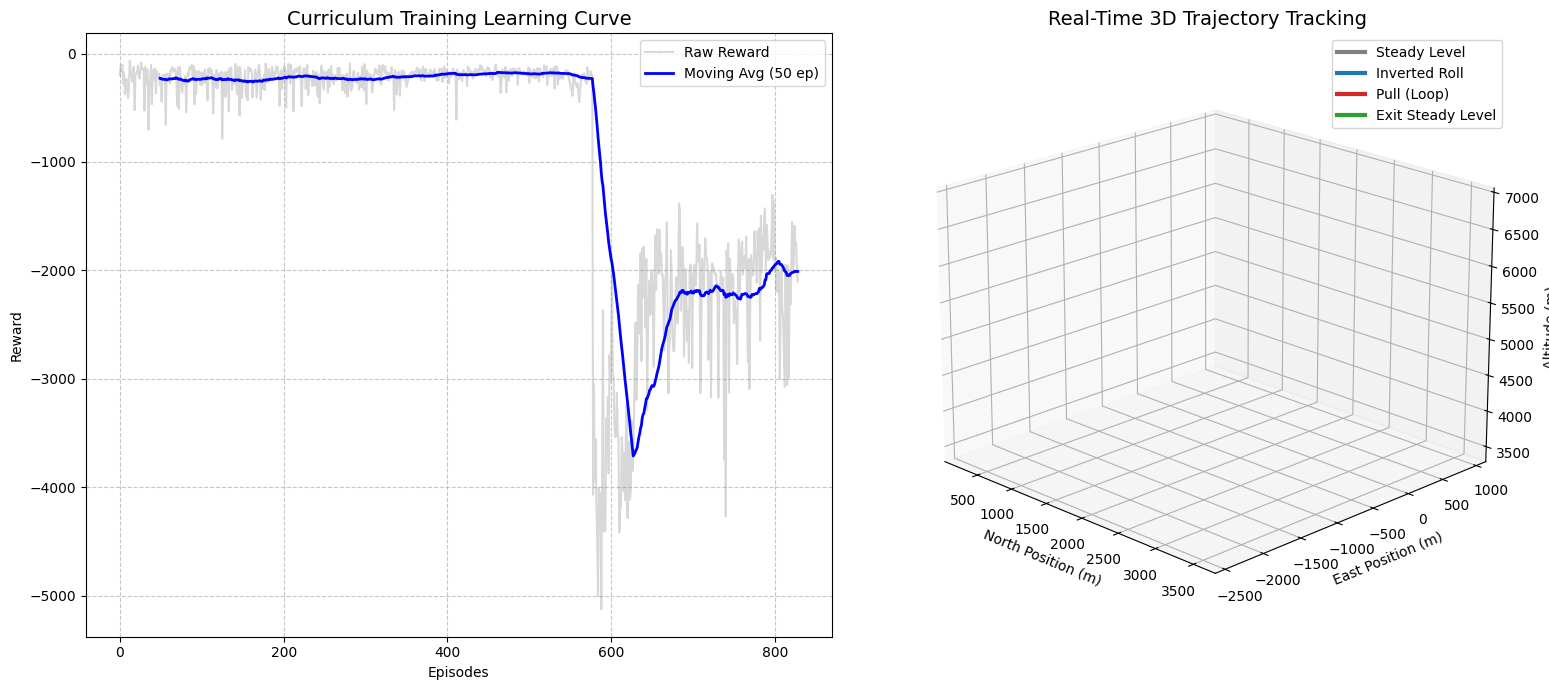

In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

class CurriculumF18Env(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.dt = 0.05
        self.g = 9.81
        self.curriculum_level = 0
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([0.0, 0.0, 6000.0, 270.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def step(self, action):
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        de, da, dr, dt_thr = action

        max_roll_rate = np.radians(225.0)
        max_pitch_rate = np.radians(30.0)
        max_yaw_rate = np.radians(15.0)

        dp = (da * max_roll_rate - p) * 5.0
        dq = (de * max_pitch_rate - q) * 4.0
        dr_rate = (dr * max_yaw_rate - r) * 2.0

        p += dp * self.dt
        q += dq * self.dt
        r += dr_rate * self.dt

        dphi = p + q * np.sin(phi) * np.tan(theta) + r * np.cos(phi) * np.tan(theta)
        dtheta = q * np.cos(phi) - r * np.sin(phi)
        dpsi = (q * np.sin(phi) + r * np.cos(phi)) / (np.cos(theta) + 1e-8)

        phi += dphi * self.dt
        theta += dtheta * self.dt
        psi += dpsi * self.dt

        V = np.sqrt(u**2 + v**2 + w**2) + 1e-8
        vx = V * np.cos(theta) * np.cos(psi)
        vy = V * np.cos(theta) * np.sin(psi)
        vz = V * np.sin(theta)

        x += vx * self.dt
        y += vy * self.dt
        z += vz * self.dt

        self.state = np.array([x, y, z, u, v, w, phi, theta, psi, p, q, r], dtype=np.float32)

        phi_err = abs(abs(phi) - np.pi) / np.pi
        psi_err = abs((psi - np.pi + np.pi) % (2*np.pi) - np.pi) / np.pi

        if self.curriculum_level == 0:
            reward = -(abs(phi) + abs(theta))
            terminated = bool(z < 5000 or self.steps > 200)
        elif self.curriculum_level == 1:
            reward = -(phi_err + abs(theta))
            terminated = bool(z < 4000 or self.steps > 300)
        else:
            progress = 1.0 - psi_err
            theta_err = (abs(theta) / (np.pi/2)) * progress
            reward = -(1.5 * phi_err + 3.0 * psi_err + 2.0 * theta_err)
            terminated = bool(z < 1000 or (psi_err < 0.05 and abs(theta) < 0.05 and abs(phi) < 0.05))

        self.steps += 1
        if self.steps > 600:
            terminated = True

        return self.state, reward, terminated, False, {}

class CurriculumCallback(BaseCallback):
    def __init__(self, step_thresholds, verbose=0):
        super().__init__(verbose)
        self.step_thresholds = step_thresholds
        self.current_level = 0

    def _on_step(self) -> bool:
        if self.current_level < len(self.step_thresholds):
            if self.num_timesteps >= self.step_thresholds[self.current_level]:
                self.current_level += 1
                self.training_env.env_method('set_attr', 'curriculum_level', self.current_level)
                if self.verbose > 0:
                    print(f"Curriculum Level Upgraded to {self.current_level} at {self.num_timesteps} steps")
        return True

    def _on_training_start(self):
        self.training_env.env_method('set_attr', 'curriculum_level', self.current_level)

def set_attr(self, name, value):
    setattr(self, name, value)
CurriculumF18Env.set_attr = set_attr

if __name__ == "__main__":
    env = DummyVecEnv([lambda: Monitor(CurriculumF18Env())])
    thresholds = [50000, 150000]
    curriculum_callback = CurriculumCallback(step_thresholds=thresholds, verbose=1)

    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4, n_steps=2048, batch_size=64)
    model.learn(total_timesteps=300000, callback=curriculum_callback)

    episode_rewards = env.envs[0].get_episode_rewards()

    eval_env = CurriculumF18Env()
    eval_env.curriculum_level = 2
    obs, _ = eval_env.reset()

    history = []
    phases = []

    for t in range(600):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = eval_env.step(action)
        history.append(obs.copy())

        phi_deg = np.degrees(obs[6])
        theta_deg = np.degrees(obs[7])
        psi_deg = np.degrees(obs[8])

        if t < 20 and abs(phi_deg) < 10:
            phases.append('Steady Level')
        elif abs(phi_deg) < 170 and abs(psi_deg) < 45:
            phases.append('Inverted Roll')
        elif abs(psi_deg) < 175:
            phases.append('Pull (Loop)')
        else:
            phases.append('Exit Steady Level')

        if done:
            break

    history = np.array(history)

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121)
    if len(episode_rewards) > 0:
        window = min(50, len(episode_rewards))
        moving_avg = pd.Series(episode_rewards).rolling(window=window).mean()
        ax1.plot(episode_rewards, alpha=0.3, color='gray', label='Raw Reward')
        ax1.plot(moving_avg, color='blue', linewidth=2, label=f'Moving Avg ({window} ep)')
        ax1.set_title('Curriculum Training Learning Curve', fontsize=14)
        ax1.set_xlabel('Episodes')
        ax1.set_ylabel('Reward')
        ax1.grid(True, linestyle='--', alpha=0.7)
        ax1.legend()

    ax2 = fig.add_subplot(122, projection='3d')
    phase_colors = {
        'Steady Level': '#808080',
        'Inverted Roll': '#1f77b4',
        'Pull (Loop)': '#d62728',
        'Exit Steady Level': '#2ca02c'
    }

    ax2.set_xlabel('North Position (m)')
    ax2.set_ylabel('East Position (m)')
    ax2.set_zlabel('Altitude (m)')
    ax2.set_title('Real-Time 3D Trajectory Tracking', fontsize=14)

    max_range = np.array([history[:,0].max()-history[:,0].min(),
                          history[:,1].max()-history[:,1].min(),
                          history[:,2].max()-history[:,2].min()]).max() / 2.0
    mid_x = (history[:,0].max()+history[:,0].min()) * 0.5
    mid_y = (history[:,1].max()+history[:,1].min()) * 0.5
    mid_z = (history[:,2].max()+history[:,2].min()) * 0.5

    ax2.set_xlim(mid_x - max_range, mid_x + max_range)
    ax2.set_ylim(mid_y - max_range, mid_y + max_range)
    ax2.set_zlim(mid_z - max_range, mid_z + max_range)
    ax2.view_init(elev=20, azim=-45)

    legend_elements = [Line2D([0], [0], color=c, lw=3, label=l) for l, c in phase_colors.items()]
    ax2.legend(handles=legend_elements, loc='upper right')

    lines = []

    def update_anim(num):
        if num == 0:
            return lines
        seg_idx = num - 1
        x_data = history[seg_idx:seg_idx+2, 0]
        y_data = history[seg_idx:seg_idx+2, 1]
        z_data = history[seg_idx:seg_idx+2, 2]
        color = phase_colors[phases[seg_idx]]

        line, = ax2.plot(x_data, y_data, z_data, color=color, linewidth=3)
        lines.append(line)
        ax2.view_init(elev=20, azim=-45 + (num * 0.1))
        return lines

    ani = animation.FuncAnimation(
        fig,
        update_anim,
        frames=len(history),
        interval=50,
        blit=False,
        repeat=False
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from typing import cast
from mpl_toolkits.mplot3d import Axes3D

class CurriculumF18Env(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.dt = 0.05
        self.g = 9.81
        self.curriculum_level = 0
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([0.0, 0.0, 6000.0, 270.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def step(self, action):
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        de, da, dr, dt_thr = action

        max_roll_rate = np.radians(225.0)
        max_pitch_rate = np.radians(30.0)
        max_yaw_rate = np.radians(15.0)

        dp = (da * max_roll_rate - p) * 5.0
        dq = (de * max_pitch_rate - q) * 4.0
        dr_rate = (dr * max_yaw_rate - r) * 2.0

        p += dp * self.dt
        q += dq * self.dt
        r += dr_rate * self.dt

        dphi = p + q * np.sin(phi) * np.tan(theta) + r * np.cos(phi) * np.tan(theta)
        dtheta = q * np.cos(phi) - r * np.sin(phi)
        dpsi = (q * np.sin(phi) + r * np.cos(phi)) / (np.cos(theta) + 1e-8)

        phi += dphi * self.dt
        theta += dtheta * self.dt
        psi += dpsi * self.dt

        V = np.sqrt(u**2 + v**2 + w**2) + 1e-8
        vx = V * np.cos(theta) * np.cos(psi)
        vy = V * np.cos(theta) * np.sin(psi)
        vz = V * np.sin(theta)

        x += vx * self.dt
        y += vy * self.dt
        z += vz * self.dt

        self.state = np.array([x, y, z, u, v, w, phi, theta, psi, p, q, r], dtype=np.float32)

        norm_phi = abs(phi) / np.pi
        phi_err = abs(abs(phi) - np.pi) / np.pi
        psi_err = abs((psi - np.pi + np.pi) % (2*np.pi) - np.pi) / np.pi
        theta_err = abs(theta) / (np.pi/2)
        alt_start_err = abs(z - 6000.0) / 1000.0
        alt_target_err = abs(z - 3000.0) / 1000.0
        heading_err_start = abs((psi + np.pi) % (2*np.pi) - np.pi) / np.pi

        if self.curriculum_level == 0:
            reward = -(norm_phi + theta_err + heading_err_start + alt_start_err)
            terminated = bool(z < 5800 or z > 6200 or self.steps > 200)

        elif self.curriculum_level == 1:
            reward = -(phi_err + theta_err + heading_err_start + 5.0 * alt_start_err)
            terminated = bool(z < 5800 or z > 6200 or self.steps > 300)

        elif self.curriculum_level == 2:
            progress = 1.0 - psi_err
            reward = -(phi_err * (1.0 - progress) + 3.0 * psi_err + alt_target_err * progress)
            terminated = bool(z < 2000 or self.steps > 500 or (psi_err < 0.1 and theta > -0.1))

        else:
            progress = 1.0 - psi_err
            maneuver_penalty = phi_err * (1.0 - progress) + 3.0 * psi_err
            exit_penalty = (norm_phi + theta_err + alt_target_err) * progress
            rate_penalty = 0.01 * (p**2 + q**2 + r**2)

            reward = -(maneuver_penalty + 2.0 * exit_penalty + rate_penalty)
            terminated = bool(z < 1000 or (psi_err < 0.05 and theta_err < 0.05 and norm_phi < 0.05 and alt_target_err < 0.2))

        self.steps += 1
        if self.steps > 600:
            terminated = True

        return self.state, reward, terminated, False, {}

class CurriculumCallback(BaseCallback):
    def __init__(self, step_thresholds, verbose=0):
        super().__init__(verbose)
        self.step_thresholds = step_thresholds
        self.current_level = 0

    def _on_step(self) -> bool:
        if self.current_level < len(self.step_thresholds):
            if self.num_timesteps >= self.step_thresholds[self.current_level]:
                self.current_level += 1
                self.training_env.set_attr('curriculum_level', self.current_level)
                if self.verbose > 0:
                    print(f"Curriculum Level Upgraded to {self.current_level} at {self.num_timesteps} steps")
        return True

    def _on_training_start(self):
        # Instead of env_method('set_attr', ...), use the VecEnv's native set_attr:
        self.training_env.set_attr('curriculum_level', self.current_level)



if __name__ == "__main__":
    # 1. Keep a direct reference to the Monitor
    monitored_env = Monitor(CurriculumF18Env())
    env = DummyVecEnv([lambda: monitored_env])

    thresholds = [50000, 150000]
    curriculum_callback = CurriculumCallback(step_thresholds=thresholds, verbose=1)

    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4, n_steps=2048, batch_size=64)
    model.learn(total_timesteps=300000, callback=curriculum_callback)

    # 2. Extract rewards safely from the direct reference
    episode_rewards = monitored_env.get_episode_rewards()

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121)
    if len(episode_rewards) > 0:
        window = min(50, len(episode_rewards))
        moving_avg = pd.Series(episode_rewards).rolling(window=window).mean()
        ax1.plot(episode_rewards, alpha=0.3, color='gray', label='Raw Reward')
        ax1.plot(moving_avg, color='blue', linewidth=2, label=f'Moving Avg ({window} ep)')
        ax1.set_title('Curriculum Training Learning Curve', fontsize=14)
        ax1.set_xlabel('Episodes')
        ax1.set_ylabel('Reward')
        ax1.grid(True, linestyle='--', alpha=0.7)
        ax1.legend()

    ax2 = cast(Axes3D, fig.add_subplot(122, projection='3d'))
    phase_colors = {
        'Steady Level': '#808080',
        'Inverted Roll': '#1f77b4',
        'Pull (Loop)': '#d62728',
        'Exit Steady Level': '#2ca02c'
    }

    ax2.set_xlabel('North Position (m)')
    ax2.set_ylabel('East Position (m)')
    ax2.set_zlabel('Altitude (m)')
    ax2.set_title('Real-Time 3D Trajectory Tracking', fontsize=14)

    ax2.set_xlim(-500, 4000)
    ax2.set_ylim(-1000, 1000)
    ax2.set_zlim(2000, 6500)
    ax2.view_init(elev=20, azim=-45)

    legend_elements = [Line2D([0], [0], color=c, lw=3, label=l) for l, c in phase_colors.items()]
    ax2.legend(handles=legend_elements, loc='upper right')

    eval_env = CurriculumF18Env()
    eval_env.curriculum_level = 2

    sim_state = {
        'obs': eval_env.reset()[0],
        'done': False,
        'history_x': [0.0],
        'history_y': [0.0],
        'history_z': [6000.0],
        'lines': []
    }

    def update_anim(frame):
        if sim_state['done']:
            return sim_state['lines']

        action, _ = model.predict(sim_state['obs'], deterministic=True)
        sim_state['obs'], reward, done, _, _ = eval_env.step(action)

        sim_state['history_x'].append(sim_state['obs'][0])
        sim_state['history_y'].append(sim_state['obs'][1])
        sim_state['history_z'].append(sim_state['obs'][2])

        phi_deg = np.degrees(sim_state['obs'][6])
        theta_deg = np.degrees(sim_state['obs'][7])
        psi_deg = np.degrees(sim_state['obs'][8])

        if frame < 20 and abs(phi_deg) < 10:
            phase = 'Steady Level'
        elif abs(phi_deg) < 170 and abs(psi_deg) < 45:
            phase = 'Inverted Roll'
        elif abs(psi_deg) < 175:
            phase = 'Pull (Loop)'
        else:
            phase = 'Exit Steady Level'

        color = phase_colors[phase]

        line, = ax2.plot(sim_state['history_x'][-2:],
                         sim_state['history_y'][-2:],
                         sim_state['history_z'][-2:],
                         color=color, linewidth=3)

        sim_state['lines'].append(line)
        ax2.view_init(elev=20, azim=-45 + (frame * 0.1))

        if done:
            sim_state['done'] = True

        return sim_state['lines']

    ani = animation.FuncAnimation(
        fig,
        update_anim,
        frames=600,
        interval=50,
        blit=False,
        repeat=False
    )

    plt.tight_layout()
    plt.show()
    from IPython.display import HTML

# Prevent the static, empty plot from showing up twice
plt.close(fig)

print("Compiling 3D animation... this will take about 30-60 seconds.")

# Convert the Matplotlib animation into an interactive Javascript widget
# This gives you a nice play/pause/scrub slider right in Colab!
html_anim = ani.to_jshtml()

# Display it in the notebook
HTML(html_anim)

Output hidden; open in https://colab.research.google.com to view.

In [3]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from typing import cast
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from IPython.display import HTML, display

mpl.rcParams['animation.embed_limit'] = 100.0

class CurriculumF18Env(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.dt = 0.05
        self.g = 9.81
        self.curriculum_level = 0
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([0.0, 0.0, 6000.0, 270.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def step(self, action):
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        de, da, dr, dt_thr = action

        max_roll_rate = np.radians(225.0)
        max_pitch_rate = np.radians(30.0)
        max_yaw_rate = np.radians(15.0)

        dp = (da * max_roll_rate - p) * 5.0
        dq = (de * max_pitch_rate - q) * 4.0
        dr_rate = (dr * max_yaw_rate - r) * 2.0

        p += dp * self.dt
        q += dq * self.dt
        r += dr_rate * self.dt

        dphi = p + q * np.sin(phi) * np.tan(theta) + r * np.cos(phi) * np.tan(theta)
        dtheta = q * np.cos(phi) - r * np.sin(phi)
        dpsi = (q * np.sin(phi) + r * np.cos(phi)) / (np.cos(theta) + 1e-8)

        phi += dphi * self.dt
        theta += dtheta * self.dt
        psi += dpsi * self.dt

        V = np.sqrt(u**2 + v**2 + w**2) + 1e-8
        vx = V * np.cos(theta) * np.cos(psi)
        vy = V * np.cos(theta) * np.sin(psi)
        vz = V * np.sin(theta)

        x += vx * self.dt
        y += vy * self.dt
        z += vz * self.dt

        self.state = np.array([x, y, z, u, v, w, phi, theta, psi, p, q, r], dtype=np.float32)

        norm_phi = abs(phi) / np.pi
        phi_err = abs(abs(phi) - np.pi) / np.pi
        psi_err = abs((psi - np.pi + np.pi) % (2*np.pi) - np.pi) / np.pi
        theta_err = abs(theta) / (np.pi/2)
        alt_start_err = abs(z - 6000.0) / 1000.0
        alt_target_err = abs(z - 3000.0) / 1000.0
        heading_err_start = abs((psi + np.pi) % (2*np.pi) - np.pi) / np.pi

        if self.curriculum_level == 0:
            reward = -(norm_phi + theta_err + heading_err_start + alt_start_err)
            terminated = bool(z < 5800 or z > 6200 or self.steps > 200)

        elif self.curriculum_level == 1:
            reward = -(phi_err + theta_err + heading_err_start + 5.0 * alt_start_err)
            terminated = bool(z < 5800 or z > 6200 or self.steps > 300)

        elif self.curriculum_level == 2:
            progress = 1.0 - psi_err
            reward = -(phi_err * (1.0 - progress) + 3.0 * psi_err + alt_target_err * progress)
            terminated = bool(z < 2000 or self.steps > 500 or (psi_err < 0.1 and theta > -0.1))

        else:
            progress = 1.0 - psi_err
            maneuver_penalty = phi_err * (1.0 - progress) + 3.0 * psi_err
            exit_penalty = (norm_phi + theta_err + alt_target_err) * progress
            rate_penalty = 0.01 * (p**2 + q**2 + r**2)

            reward = -(maneuver_penalty + 2.0 * exit_penalty + rate_penalty)
            terminated = bool(z < 1000 or (psi_err < 0.05 and theta_err < 0.05 and norm_phi < 0.05 and alt_target_err < 0.2))

        self.steps += 1
        if self.steps > 600:
            terminated = True

        return self.state, reward, terminated, False, {}

class CurriculumCallback(BaseCallback):
    def __init__(self, step_thresholds, verbose=0):
        super().__init__(verbose)
        self.step_thresholds = step_thresholds
        self.current_level = 0

    def _on_step(self) -> bool:
        if self.current_level < len(self.step_thresholds):
            if self.num_timesteps >= self.step_thresholds[self.current_level]:
                self.current_level += 1
                self.training_env.set_attr('curriculum_level', self.current_level)
        return True

    def _on_training_start(self):
        self.training_env.set_attr('curriculum_level', self.current_level)

if __name__ == "__main__":
    monitored_env = Monitor(CurriculumF18Env())
    env = DummyVecEnv([lambda: monitored_env])

    thresholds = [400, 800, 1500]
    curriculum_callback = CurriculumCallback(step_thresholds=thresholds, verbose=0)

    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4, n_steps=2048, batch_size=64)
    model.learn(total_timesteps=2500, callback=curriculum_callback)

    episode_rewards = monitored_env.get_episode_rewards()

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121)
    if len(episode_rewards) > 0:
        window = min(50, len(episode_rewards))
        moving_avg = pd.Series(episode_rewards).rolling(window=window).mean()
        ax1.plot(episode_rewards, alpha=0.3, color='gray', label='Raw Reward')
        ax1.plot(moving_avg, color='blue', linewidth=2, label=f'Moving Avg ({window} ep)')
        ax1.set_title('Curriculum Training Learning Curve', fontsize=14)
        ax1.set_xlabel('Episodes')
        ax1.set_ylabel('Reward')
        ax1.grid(True, linestyle='--', alpha=0.7)
        ax1.legend()

    ax2 = cast(Axes3D, fig.add_subplot(122, projection='3d'))
    phase_colors = {
        'Steady Level': '#808080',
        'Inverted Roll': '#1f77b4',
        'Pull (Loop)': '#d62728',
        'Exit Steady Level': '#2ca02c'
    }

    ax2.set_xlabel('North Position (m)')
    ax2.set_ylabel('East Position (m)')
    ax2.set_zlabel('Altitude (m)')
    ax2.set_title('Real-Time 3D Trajectory Tracking', fontsize=14)

    ax2.set_xlim(-500, 4000)
    ax2.set_ylim(-1000, 1000)
    ax2.set_zlim(2000, 6500)
    ax2.view_init(elev=20, azim=-45)

    legend_elements = [Line2D([0], [0], color=c, lw=3, label=l) for l, c in phase_colors.items()]
    ax2.legend(handles=legend_elements, loc='upper right')

    eval_env = CurriculumF18Env()
    eval_env.curriculum_level = 3

    sim_state = {
        'obs': eval_env.reset()[0],
        'done': False,
        'history_x': [0.0],
        'history_y': [0.0],
        'history_z': [6000.0],
        'lines': []
    }

    def update_anim(frame):
        if sim_state['done']:
            return sim_state['lines']

        action, _ = model.predict(sim_state['obs'], deterministic=True)
        sim_state['obs'], _, done, _, _ = eval_env.step(action)

        sim_state['history_x'].append(sim_state['obs'][0])
        sim_state['history_y'].append(sim_state['obs'][1])
        sim_state['history_z'].append(sim_state['obs'][2])

        phi_deg = np.degrees(sim_state['obs'][6])
        theta_deg = np.degrees(sim_state['obs'][7])
        psi_deg = np.degrees(sim_state['obs'][8])

        if frame < 20 and abs(phi_deg) < 10:
            phase = 'Steady Level'
        elif abs(phi_deg) < 170 and abs(psi_deg) < 45:
            phase = 'Inverted Roll'
        elif abs(psi_deg) < 175:
            phase = 'Pull (Loop)'
        else:
            phase = 'Exit Steady Level'

        color = phase_colors[phase]

        line, = ax2.plot(sim_state['history_x'][-2:],
                         sim_state['history_y'][-2:],
                         sim_state['history_z'][-2:],
                         color=color, linewidth=3)

        sim_state['lines'].append(line)
        ax2.view_init(elev=20, azim=-45 + (frame * 0.1))

        if done:
            sim_state['done'] = True

        return sim_state['lines']

    ani = animation.FuncAnimation(
        fig,
        update_anim,
        frames=600,
        interval=50,
        blit=False,
        repeat=False
    )

    plt.close(fig)
    display(HTML(ani.to_jshtml()))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from typing import cast
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from IPython.display import HTML, display

mpl.rcParams['animation.embed_limit'] = 100.0

# ─────────────────────────────────────────────────────────────────────────────
# Split-S Maneuver Phase Definitions
# ─────────────────────────────────────────────────────────────────────────────
#
#  Phase 0 – STEADY LEVEL FLIGHT
#    Aircraft flies straight-and-level at entry altitude (~6 000 m).
#    Goal: wings level (phi ≈ 0), zero pitch/yaw rate, stable altitude.
#
#  Phase 1 – INVERTED ROLL
#    Aircraft rolls 180 ° to wings-inverted (phi ≈ ±π).
#    Goal: reach |phi| ≈ π quickly while keeping theta ≈ 0 and
#    maintaining altitude so we have room to pull.
#
#  Phase 2 – PULL-THROUGH (half-loop descent)
#    From inverted, aircraft pulls back (positive pitch rate) to
#    trace a half-loop, descending ~3 000 m and reversing heading
#    (Δpsi ≈ 180 °).  Goal: psi → entry_psi+π, theta → 0,
#    altitude falls to ~3 000 m.
#
#  Phase 3 – EXIT STEADY LEVEL FLIGHT
#    Aircraft exits the loop wings-level at the new (reversed) heading
#    and lower altitude (~3 000 m).
#    Goal: phi ≈ 0, theta ≈ 0, stable altitude, psi stable.
#
# ─────────────────────────────────────────────────────────────────────────────

ENTRY_ALT   = 6000.0   # m  – altitude at start of maneuver
EXIT_ALT    = 3000.0   # m  – target altitude after pull-through
FLOOR_ALT   =  500.0   # m  – hard deck / automatic termination
ENTRY_PSI   = 0.0      # rad – initial heading (East)


def _angle_err(a, b):
    """Smallest signed angular difference a-b in [-π, π]."""
    return (a - b + np.pi) % (2 * np.pi) - np.pi


class SplitSF18Env(gym.Env):
    """
    F-18 environment structured around the four phases of the Split-S maneuver.
    A single `curriculum_level` integer selects which phase is active so the
    same callback-based curriculum used before still works.
    """

    # ── phase indices ──────────────────────────────────────────────────────
    PHASE_STEADY_ENTRY  = 0
    PHASE_INVERTED_ROLL = 1
    PHASE_PULL_THROUGH  = 2
    PHASE_STEADY_EXIT   = 3

    def __init__(self):
        super().__init__()
        # Actions: [elevator, aileron, rudder, throttle] ∈ [-1, 1]
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        # State: [x, y, z, u, v, w, phi, theta, psi, p, q, r]
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)

        self.dt = 0.05          # integration time-step  (s)
        self.g  = 9.81
        self.curriculum_level = 0

        # Per-phase episode step limits (generous to allow completion)
        self._max_steps = {
            self.PHASE_STEADY_ENTRY:  150,
            self.PHASE_INVERTED_ROLL: 200,
            self.PHASE_PULL_THROUGH:  400,
            self.PHASE_STEADY_EXIT:   200,
        }
        self.reset()

    # ── reset ──────────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        phase = self.curriculum_level

        if phase == self.PHASE_STEADY_ENTRY:
            # Wings-level, straight-and-level at entry altitude
            self.state = np.array([0, 0, ENTRY_ALT,
                                   270, 0, 0,          # u,v,w (airspeed ~270 m/s)
                                   0, 0, ENTRY_PSI,    # phi, theta, psi
                                   0, 0, 0],           # p, q, r
                                  dtype=np.float32)

        elif phase == self.PHASE_INVERTED_ROLL:
            # Start level, must roll to inverted
            self.state = np.array([0, 0, ENTRY_ALT,
                                   270, 0, 0,
                                   0, 0, ENTRY_PSI,
                                   0, 0, 0],
                                  dtype=np.float32)

        elif phase == self.PHASE_PULL_THROUGH:
            # Start already inverted (phi=π), theta=0, entry altitude
            self.state = np.array([0, 0, ENTRY_ALT,
                                   270, 0, 0,
                                   np.pi, 0, ENTRY_PSI,
                                   0, 0, 0],
                                  dtype=np.float32)
            self._pull_entry_psi = ENTRY_PSI

        elif phase == self.PHASE_STEADY_EXIT:
            # Start wings-level at exit altitude with reversed heading
            exit_psi = (ENTRY_PSI + np.pi) % (2 * np.pi)
            self.state = np.array([0, 0, EXIT_ALT,
                                   270, 0, 0,
                                   0, 0, exit_psi,
                                   0, 0, 0],
                                  dtype=np.float32)

        self.steps = 0
        self._phase_done = False
        return self.state, {}

    # ── dynamics ───────────────────────────────────────────────────────────
    def _integrate(self, action):
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        de, da, dr, dt_thr = action

        # Rate command model (simplified fly-by-wire)
        max_roll_rate  = np.radians(225.0)
        max_pitch_rate = np.radians(45.0)   # increased for tighter pull
        max_yaw_rate   = np.radians(15.0)

        dp_cmd = da * max_roll_rate
        dq_cmd = de * max_pitch_rate
        dr_cmd = dr * max_yaw_rate

        p += (dp_cmd - p) * 5.0 * self.dt
        q += (dq_cmd - q) * 4.0 * self.dt
        r += (dr_cmd - r) * 2.0 * self.dt

        # Euler angle kinematics
        cos_phi   = np.cos(phi);  sin_phi = np.sin(phi)
        tan_theta = np.tan(theta);cos_theta = np.cos(theta) + 1e-8

        dphi   = p + (q * sin_phi + r * cos_phi) * tan_theta
        dtheta = q * cos_phi - r * sin_phi
        dpsi   = (q * sin_phi + r * cos_phi) / cos_theta

        phi   += dphi   * self.dt
        theta += dtheta * self.dt
        psi   += dpsi   * self.dt

        # Keep phi in [-2π, 2π] for easier error computation
        phi   = np.clip(phi,   -2 * np.pi, 2 * np.pi)
        theta = np.clip(theta, -np.pi / 2 * 0.98, np.pi / 2 * 0.98)

        # Translational kinematics (flat-earth)
        V  = np.sqrt(u**2 + v**2 + w**2) + 1e-8
        vx = V * np.cos(theta) * np.cos(psi)
        vy = V * np.cos(theta) * np.sin(psi)
        vz = V * np.sin(theta)

        x += vx * self.dt
        y += vy * self.dt
        z += vz * self.dt

        self.state = np.array([x, y, z, u, v, w, phi, theta, psi, p, q, r], dtype=np.float32)

    # ── reward & termination per phase ─────────────────────────────────────
    def step(self, action):
        self._integrate(action)
        x, y, z, u, v, w, phi, theta, psi, p, q, r = self.state
        self.steps += 1
        phase = self.curriculum_level

        # ── hard-deck / common termination ──────────────────────────────
        hit_floor = bool(z < FLOOR_ALT)

        # ── normalised error helpers ─────────────────────────────────────
        def alt_err(target): return abs(z - target) / 1000.0
        phi_level  = abs(phi) / np.pi          # 0 = wings level, 1 = inverted
        phi_inv    = abs(abs(phi) - np.pi) / np.pi  # 0 = perfectly inverted
        theta_err  = abs(theta) / (np.pi / 2)
        rate_pen   = 0.05 * (p**2 + q**2 + r**2)  # angular rate damping

        # ────────────────────────────────────────────────────────────────
        # PHASE 0 – STEADY LEVEL FLIGHT (entry)
        # ────────────────────────────────────────────────────────────────
        if phase == self.PHASE_STEADY_ENTRY:
            # Reward: wings level, zero pitch, maintain entry altitude, low rates
            reward = (
                - 2.0 * phi_level          # penalise bank angle
                - 2.0 * theta_err          # penalise pitch deviation
                - 1.5 * alt_err(ENTRY_ALT) # maintain altitude
                - rate_pen                 # damp angular rates
            )
            # Success: sustained level flight
            success = bool(
                phi_level   < 0.05 and
                theta_err   < 0.05 and
                alt_err(ENTRY_ALT) < 0.05
            )
            terminated = hit_floor or success or self.steps >= self._max_steps[phase]

        # ────────────────────────────────────────────────────────────────
        # PHASE 1 – INVERTED ROLL
        # ────────────────────────────────────────────────────────────────
        elif phase == self.PHASE_INVERTED_ROLL:
            # Reward: drive phi → ±π quickly; keep theta ≈ 0; preserve altitude
            roll_progress = -phi_inv              # improves as we approach inverted
            reward = (
                + 3.0 * roll_progress            # main goal: roll to inverted
                - 2.0 * theta_err                # keep nose level during roll
                - 1.0 * alt_err(ENTRY_ALT)       # don't lose altitude yet
                - rate_pen
            )
            # Bonus: snap reward for reaching inverted
            if phi_inv < 0.05 and theta_err < 0.10:
                reward += 5.0
                self._phase_done = True

            # Allow some altitude loss (up to 500 m) to avoid impossible constraint
            terminated = bool(
                hit_floor or
                z < ENTRY_ALT - 500 or
                self._phase_done or
                self.steps >= self._max_steps[phase]
            )

        # ────────────────────────────────────────────────────────────────
        # PHASE 2 – PULL-THROUGH (half-loop descent)
        # ────────────────────────────────────────────────────────────────
        elif phase == self.PHASE_PULL_THROUGH:
            # Target heading: reversed (entry_psi + π)
            target_psi = (ENTRY_PSI + np.pi) % (2 * np.pi)
            psi_err    = abs(_angle_err(psi, target_psi)) / np.pi
            alt_prog   = (ENTRY_ALT - z) / (ENTRY_ALT - EXIT_ALT)  # 0→1 as we descend
            alt_prog   = np.clip(alt_prog, 0.0, 1.0)
            final_alt_err = alt_err(EXIT_ALT)

            # Encourage arc: push forward on throttle, pull elevator
            # At exit: wings level, theta ≈ 0, heading reversed, altitude ~EXIT_ALT
            reward = (
                + 2.0 * alt_prog           # reward for making progress downward
                - 2.0 * phi_inv            # want to end wings-level (phi→0 at exit)
                - 3.0 * psi_err            # drive to reversed heading
                - 2.0 * theta_err          # nose level at exit
                - 1.5 * final_alt_err      # hit exit altitude
                - rate_pen
            )
            # Bonus: complete pull-through
            success = bool(
                psi_err   < 0.08 and
                phi_inv   > 0.85 and       # still inverted → means phi_level < 0.15
                theta_err < 0.10 and
                alt_err(EXIT_ALT) < 0.30
            )
            # Alternate success: reached exit altitude with reversed heading
            success2 = bool(
                psi_err          < 0.10 and
                alt_err(EXIT_ALT)< 0.20 and
                theta_err        < 0.15
            )
            if success or success2:
                reward += 8.0
                self._phase_done = True

            terminated = bool(
                hit_floor or
                self._phase_done or
                self.steps >= self._max_steps[phase]
            )

        # ────────────────────────────────────────────────────────────────
        # PHASE 3 – EXIT STEADY LEVEL FLIGHT
        # ────────────────────────────────────────────────────────────────
        else:
            exit_psi    = (ENTRY_PSI + np.pi) % (2 * np.pi)
            psi_err     = abs(_angle_err(psi, exit_psi)) / np.pi

            # Reward: wings level, zero pitch, hold exit altitude, reversed heading
            reward = (
                - 3.0 * phi_level           # must be wings level
                - 2.0 * theta_err           # nose level
                - 1.5 * alt_err(EXIT_ALT)   # hold exit altitude
                - 2.0 * psi_err             # maintain reversed heading
                - rate_pen
            )
            # Bonus: successfully flying straight-and-level on new heading
            success = bool(
                phi_level          < 0.05 and
                theta_err          < 0.05 and
                alt_err(EXIT_ALT)  < 0.10 and
                psi_err            < 0.08
            )
            if success:
                reward += 10.0
                self._phase_done = True

            terminated = bool(
                hit_floor or
                self._phase_done or
                self.steps >= self._max_steps[phase]
            )

        return self.state, float(reward), terminated, False, {}


# ─────────────────────────────────────────────────────────────────────────────
# Curriculum Callback
# ─────────────────────────────────────────────────────────────────────────────
class CurriculumCallback(BaseCallback):
    def __init__(self, step_thresholds, verbose=0):
        super().__init__(verbose)
        self.step_thresholds = step_thresholds
        self.current_level   = 0

    def _on_training_start(self):
        self.training_env.set_attr('curriculum_level', 0)

    def _on_step(self) -> bool:
        if self.current_level < len(self.step_thresholds):
            if self.num_timesteps >= self.step_thresholds[self.current_level]:
                self.current_level += 1
                self.training_env.set_attr('curriculum_level', self.current_level)
                if self.verbose:
                    print(f"\n[Curriculum] → Phase {self.current_level} at step {self.num_timesteps}")
        return True


# ─────────────────────────────────────────────────────────────────────────────
# Full Split-S evaluation env (all 4 phases stitched together)
# ─────────────────────────────────────────────────────────────────────────────
class FullSplitSEnv(gym.Env):
    """Runs all four Split-S phases in sequence for visualisation."""

    PHASE_LABELS = ["Steady Level (Entry)", "Inverted Roll", "Pull-Through", "Steady Level (Exit)"]
    PHASE_COLORS = ["#808080", "#1f77b4", "#d62728", "#2ca02c"]
    PHASE_STEP_LIMITS = [100, 180, 350, 150]  # steps per phase

    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.dt = 0.05
        self._inner = SplitSF18Env()
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._phase = 0
        self._inner.curriculum_level = 0
        obs, _ = self._inner.reset()
        self.phase_label = self.PHASE_LABELS[0]
        self.phase_color = self.PHASE_COLORS[0]
        return obs, {}

    def step(self, action):
        obs, reward, terminated, truncated, info = self._inner.step(action)

        if terminated:
            self._phase += 1
            if self._phase >= 4:
                return obs, reward, True, False, info

            # Hand off: seed next phase with current state
            self._inner.curriculum_level = self._phase
            next_obs, _ = self._inner.reset()

            # Override position/heading continuity
            # (keep x,y,z and psi from previous state)
            next_obs[0]  = obs[0]   # x
            next_obs[1]  = obs[1]   # y
            next_obs[2]  = obs[2]   # z
            next_obs[8]  = obs[8]   # psi
            self._inner.state = next_obs.copy()

        self.phase_label = self.PHASE_LABELS[self._phase]
        self.phase_color = self.PHASE_COLORS[self._phase]
        return self._inner.state, reward, False, False, info


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # ── Training ────────────────────────────────────────────────────────────
    monitored_env = Monitor(SplitSF18Env())
    env = DummyVecEnv([lambda: monitored_env])

    # Advance phase every N timesteps:
    #   Phase 0 →  50k   steady entry
    #   Phase 1 → 100k   inverted roll
    #   Phase 2 → 175k   pull-through
    #   Phase 3 → 250k   steady exit
    thresholds = [50_000, 100_000, 175_000]
    curriculum_callback = CurriculumCallback(step_thresholds=thresholds, verbose=1)

    model = PPO(
        "MlpPolicy", env,
        verbose=0,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.01,       # encourage exploration
    )
    model.learn(total_timesteps=250_000, callback=curriculum_callback)

    episode_rewards = monitored_env.get_episode_rewards()

    # ── Figure layout ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 8))
    fig.patch.set_facecolor('#0d0d0d')

    # Left: learning curve
    ax1 = fig.add_subplot(121)
    ax1.set_facecolor('#111111')
    if len(episode_rewards) > 0:
        window = min(50, len(episode_rewards))
        moving_avg = pd.Series(episode_rewards).rolling(window=window).mean()
        ax1.plot(episode_rewards, alpha=0.25, color='#aaaaaa', linewidth=0.8, label='Raw Reward')
        ax1.plot(moving_avg, color='#00d4ff', linewidth=2.2, label=f'Moving Avg ({window} ep)')

        # Shade curriculum phases
        total_ep = len(episode_rewards)
        for lvl, (col, label) in enumerate(zip(
                ['#808080', '#1f77b4', '#d62728', '#2ca02c'],
                ['Phase 0: Steady', 'Phase 1: Roll', 'Phase 2: Pull', 'Phase 3: Exit'])):
            frac_start = [0, 0.2, 0.4, 0.7][lvl]
            frac_end   = [0.2, 0.4, 0.7, 1.0][lvl]
            ax1.axvspan(total_ep * frac_start, total_ep * frac_end,
                        alpha=0.08, color=col, label=label)

        ax1.set_title('Split-S Curriculum Learning Curve', color='white', fontsize=13, pad=10)
        ax1.set_xlabel('Episodes', color='#aaaaaa')
        ax1.set_ylabel('Reward', color='#aaaaaa')
        ax1.tick_params(colors='#aaaaaa')
        for spine in ax1.spines.values():
            spine.set_edgecolor('#333333')
        ax1.grid(True, linestyle='--', alpha=0.3, color='#555555')
        ax1.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white')

    # Right: 3-D trajectory
    ax2 = cast(Axes3D, fig.add_subplot(122, projection='3d'))
    ax2.set_facecolor('#111111')
    ax2.xaxis.pane.fill = ax2.yaxis.pane.fill = ax2.zaxis.pane.fill = False
    ax2.xaxis.pane.set_edgecolor('#222222')
    ax2.yaxis.pane.set_edgecolor('#222222')
    ax2.zaxis.pane.set_edgecolor('#222222')
    ax2.tick_params(colors='#aaaaaa')
    ax2.set_xlabel('North (m)', color='#aaaaaa', labelpad=8)
    ax2.set_ylabel('East  (m)', color='#aaaaaa', labelpad=8)
    ax2.set_zlabel('Alt   (m)', color='#aaaaaa', labelpad=8)
    ax2.set_title('Split-S Maneuver – 3-D Trajectory', color='white', fontsize=13, pad=10)
    ax2.set_xlim(-500, 6000)
    ax2.set_ylim(-2000, 2000)
    ax2.set_zlim(FLOOR_ALT, ENTRY_ALT + 500)
    ax2.view_init(elev=22, azim=-50)

    # Altitude reference planes
    for alt, col, lbl in [(ENTRY_ALT, '#808080', 'Entry 6000 m'),
                           (EXIT_ALT,  '#2ca02c', 'Exit  3000 m')]:
        xx, yy = np.meshgrid([-500, 6000], [-2000, 2000])
        ax2.plot_surface(xx, yy, np.full_like(xx, alt),
                         alpha=0.06, color=col, linewidth=0)

    # Phase legend
    legend_elements = [
        Line2D([0], [0], color=c, lw=3, label=l)
        for l, c in zip(FullSplitSEnv.PHASE_LABELS, FullSplitSEnv.PHASE_COLORS)
    ]
    ax2.legend(handles=legend_elements, loc='upper right',
               facecolor='#1a1a1a', labelcolor='white', fontsize=9)

    plt.tight_layout()

    # ── Evaluation & Animation ───────────────────────────────────────────────
    eval_env = FullSplitSEnv()
    obs, _ = eval_env.reset()

    sim = dict(
        obs=obs, done=False,
        hx=[obs[0]], hy=[obs[1]], hz=[obs[2]],
        colors=[], lines=[]
    )

    def update_anim(frame):
        if sim['done']:
            return sim['lines']

        action, _ = model.predict(sim['obs'], deterministic=True)
        sim['obs'], _, done, _, _ = eval_env.step(action)

        sim['hx'].append(float(sim['obs'][0]))
        sim['hy'].append(float(sim['obs'][1]))
        sim['hz'].append(float(sim['obs'][2]))
        sim['colors'].append(eval_env.phase_color)

        if len(sim['hx']) >= 2:
            line, = ax2.plot(sim['hx'][-2:], sim['hy'][-2:], sim['hz'][-2:],
                             color=eval_env.phase_color, linewidth=3, alpha=0.9)
            sim['lines'].append(line)

        # Slow camera rotation
        ax2.view_init(elev=22, azim=-50 + frame * 0.15)

        if done:
            sim['done'] = True

        return sim['lines']

    total_frames = sum(FullSplitSEnv.PHASE_STEP_LIMITS) + 50

    ani = animation.FuncAnimation(
        fig, update_anim,
        frames=total_frames,
        interval=40,
        blit=False,
        repeat=False
    )

    plt.close(fig)
    display(HTML(ani.to_jshtml()))


[Curriculum] → Phase 1 at step 50000

[Curriculum] → Phase 2 at step 100000

[Curriculum] → Phase 3 at step 175000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Buffered data was truncated after reaching the output size limit.